<h1 align=center> Projeto ECAC Meta 1 </h1>
<div align=center>
<strong>Trabalho realizado por:</strong><br>
  André Ramos | 2023227306<br>
  Rodrigo Oliveira | 2023231040
</div>

# Introdução

O presente relatório descreve o desenvolvimento e análise de uma pipeline de processamento de dados biométricos no contexto do reconhecimento de atividades humanas. O objetivo principal é compreender e aplicar as etapas fundamentais de uma análise de dados: preparação, limpeza, extração de características e redução/selecção de features. Foram utilizados dados do dataset FORTH-TRACE, que contém medições de sensores inerciais (acelerómetro, giroscópio e magnetómetro) recolhidos de 15 participantes em 16 atividades distintas. O código foi desenvolvido em Python, recorrendo essencialmente às bibliotecas NumPy, SciPy, scikit-learn e matplotlib.

# Metodologia

O código principal foi implementado no ficheiro 'main.py', estruturado em funções modulares que permitem realizar cada uma das tarefas solicitadas no enunciado. As principais fases são: (i) carregamento e organização dos dados; (ii) análise e tratamento de outliers; (iii) extração e transformação de características; (iv) redução de dimensionalidade e seleção de features.

In [2]:
import numpy as np
import csv
import os
import matplotlib.pyplot as plt
from scipy.stats import kstest, f_oneway, kruskal
from scipy.signal import welch
from sklearn.decomposition import PCA

### 2.

In [3]:

def load_participant_data(participant_id,
                          data_folder=r'C:\Users\rodri\Desktop\Universidade\3.1\ECAC\projeto\FORTH_TRACE_DATASET-master'):
    participant_folder = os.path.join(data_folder, f'part{participant_id}')
    all_data = []

    # Carregar dados dos 5 dispositivos
    for device_id in range(1, 6):
        filename = f'part{participant_id}dev{device_id}.csv'
        filepath = os.path.join(participant_folder, filename)

        try:
            with open(filepath, 'r') as csvfile:
                csv_reader = csv.reader(csvfile)
                for row in csv_reader:
                    try:
                        data_row = [float(value) for value in row]
                        all_data.append(data_row)
                    except ValueError:
                        continue
        except FileNotFoundError:
            print(f"Aviso: Ficheiro {filename} não encontrado.")
            continue

    data_array = np.array(all_data)
    return data_array

participant_id = 2
data = load_participant_data(participant_id)
print(f" Dados carregados: {data.shape}")
X_accel = X_gyro = X_mag = y_accel = y_gyro = y_mag = None

data_temp = []
datas_list = {participant_id: data}
for i in range(0, 15):
    data_temp = load_participant_data(i)
    datas_list[i] = data_temp



 Dados carregados: (266240, 12)


# 3 Análise e tratamento de outliers

## 3.1 Boxplots por atividade

Primeiramente são implementadas duas funções. ‘calculate_vector_magnitude’ calcula a magnitude de um determinado vetor, que é a raiz quadrada da soma dos quadrados das componentes (x, y, z). Com a ajuda da função anterior, ‘plot_boxplot_by_activity’ apresenta os boxplots por atividade. Esta visualização permite observar a distribuição dos dados e possíveis valores extremos (outliers).

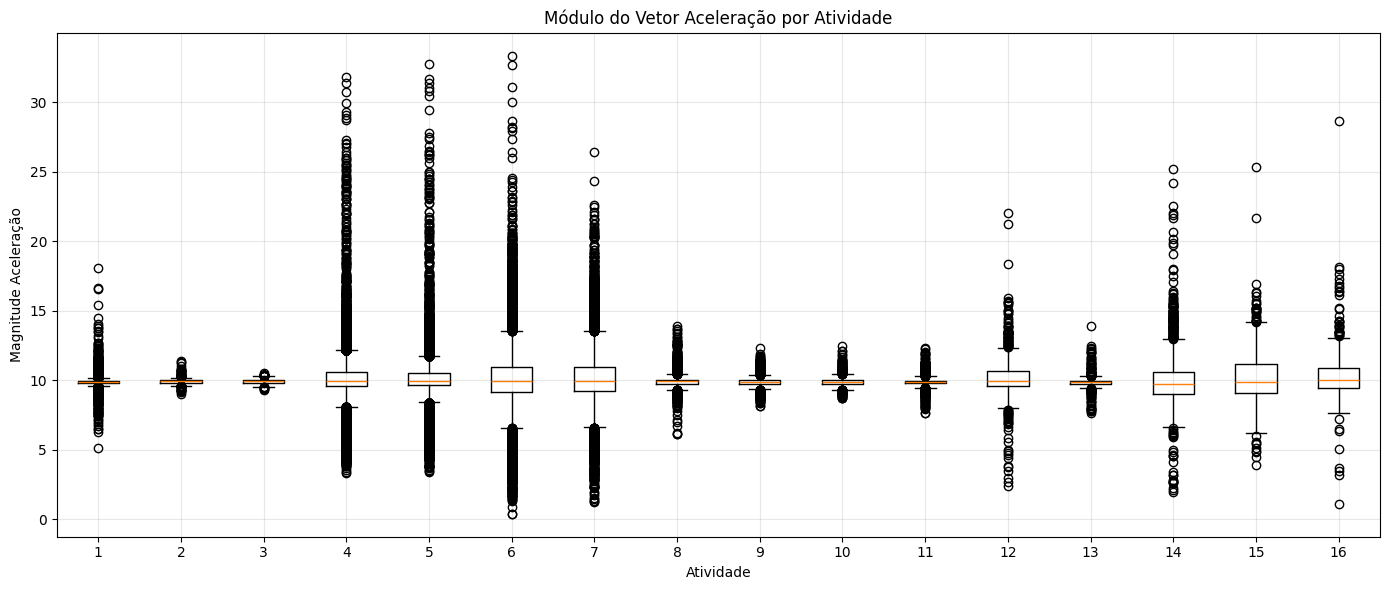

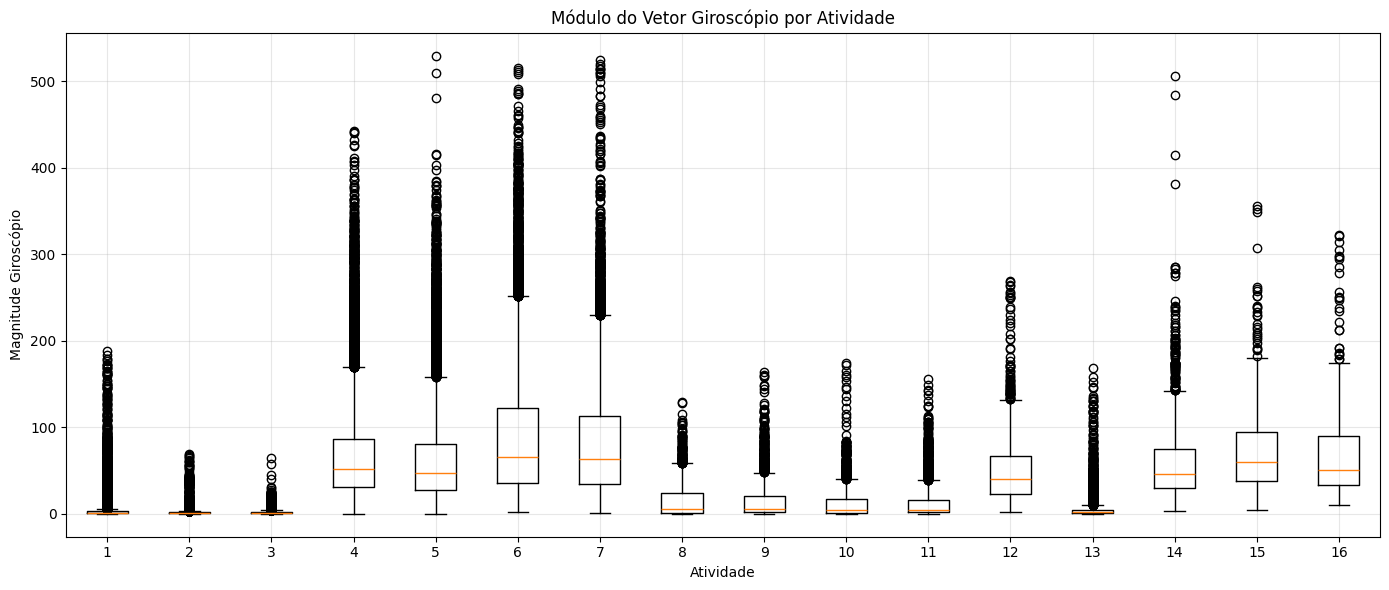

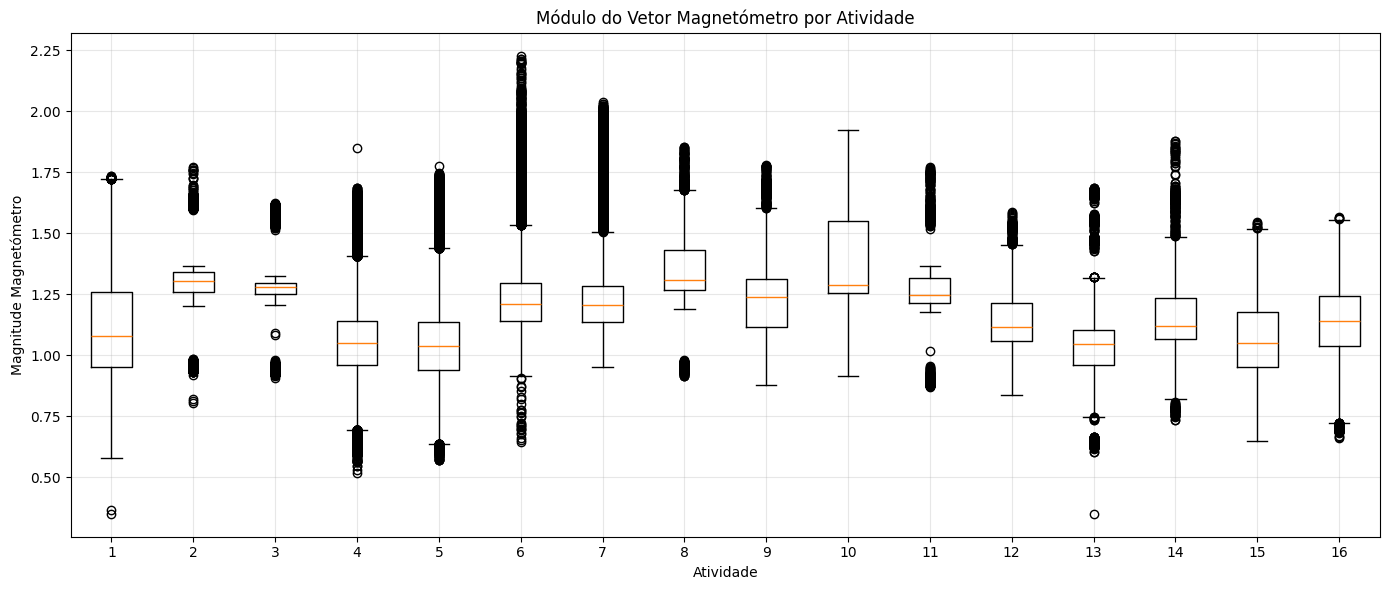

In [4]:

def calculate_vector_magnitude(data_array, start_col):
    x = data_array[:, start_col]
    y = data_array[:, start_col + 1]
    z = data_array[:, start_col + 2]

    magnitude = np.sqrt(x ** 2 + y ** 2 + z ** 2)

    return magnitude

def plot_boxplot_by_activity(data_array, vector_type='accel'):
    # Definir coluna inicial baseada no tipo de vetor
    if vector_type == 'accel':
        start_col = 1
        title = 'Módulo do Vetor Aceleração por Atividade'
        ylabel = 'Magnitude Aceleração'
    elif vector_type == 'gyro':
        start_col = 4
        title = 'Módulo do Vetor Giroscópio por Atividade'
        ylabel = 'Magnitude Giroscópio'
    elif vector_type == 'mag':
        start_col = 7
        title = 'Módulo do Vetor Magnetómetro por Atividade'
        ylabel = 'Magnitude Magnetómetro'
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    # Calcular o módulo do vetor
    magnitude = calculate_vector_magnitude(data_array, start_col)

    # Obter as atividades
    activities = data_array[:, 11]

    # Obter atividades únicas e ordenar
    unique_activities = np.sort(np.unique(activities))

    # Preparar dados para o boxplot
    data_by_activity = []
    for activity in unique_activities:
        mask = activities == activity
        data_by_activity.append(magnitude[mask])

    # Criar o boxplot
    plt.figure(figsize=(14, 6))
    plt.boxplot(data_by_activity, tick_labels=unique_activities.astype(int))
    plt.xlabel('Atividade')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show(block=False)

for v in ['accel', 'gyro', 'mag']:
    plot_boxplot_by_activity( data, vector_type=v)

## 3.2 Densidade de outliers (IQR – Tukey)

A função 'calcular_densidade_outliers' implementa a deteção de outliers com base no método IQR (Interquartile Range), usando especificamente o dispositivo do pulso direito (device ID = 2). Para cada atividade, são calculados os limites inferior e superior (Q1 - 1.5*IQR e Q3 + 1.5*IQR). Os pontos fora deste intervalo são classificados como outliers e a densidade é dada por d = (no/nr)*100, sendo ‘no’ o número de outliers e ‘nr’ o número total de amostras. Este método permite avaliar a robustez dos sensores e a variabilidade das atividades.

In [5]:
def calcular_densidade_outliers(data_array, vector_type='accel', k=3):

    if vector_type == 'accel':
        start_col = 1
    elif vector_type == 'gyro':
        start_col = 4
    elif vector_type == 'mag':
        start_col = 7
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    # Escolher o dispositivo (pulso direito)
    mask_device = data_array[:, 0] == 2
    data_filtered = data_array[mask_device]

    magnitude = calculate_vector_magnitude(data_filtered, start_col)
    activities = data_filtered[:, 11]
    unique_activities = np.sort(np.unique(activities))

    densidades = {}
    for activity in unique_activities:
        mask = activities == activity
        dados_atividade = magnitude[mask]

        # --- Método IQR (Tukey) ---
        Q1 = np.percentile(dados_atividade, 25)
        Q3 = np.percentile(dados_atividade, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = dados_atividade[(dados_atividade < lower_bound) | (dados_atividade > upper_bound)]

        no = len(outliers)
        nr = len(dados_atividade)
        densidade = (no / nr) * 100 if nr > 0 else 0
        densidades[int(activity)] = densidade

    print(f"\nDensidades de outliers ({vector_type},):")
    for a, d in densidades.items():
        print(f"  Atividade {a}: {d:.2f}%")

    return densidades


for v in ['accel', 'gyro', 'mag']:
    calcular_densidade_outliers (data, vector_type=v, k=3)


Densidades de outliers (accel,):
  Atividade 1: 3.43%
  Atividade 2: 3.98%
  Atividade 3: 4.05%
  Atividade 4: 1.68%
  Atividade 5: 2.36%
  Atividade 6: 4.47%
  Atividade 7: 2.41%
  Atividade 8: 24.61%
  Atividade 9: 23.70%
  Atividade 10: 24.22%
  Atividade 11: 18.49%
  Atividade 12: 3.15%
  Atividade 13: 0.79%
  Atividade 14: 11.02%
  Atividade 15: 2.36%
  Atividade 16: 1.57%

Densidades de outliers (gyro,):
  Atividade 1: 6.82%
  Atividade 2: 5.34%
  Atividade 3: 8.59%
  Atividade 4: 1.85%
  Atividade 5: 1.46%
  Atividade 6: 1.20%
  Atividade 7: 3.12%
  Atividade 8: 3.52%
  Atividade 9: 2.08%
  Atividade 10: 7.62%
  Atividade 11: 11.20%
  Atividade 12: 3.54%
  Atividade 13: 1.18%
  Atividade 14: 8.66%
  Atividade 15: 10.24%
  Atividade 16: 12.60%

Densidades de outliers (mag,):
  Atividade 1: 0.00%
  Atividade 2: 2.11%
  Atividade 3: 0.05%
  Atividade 4: 0.14%
  Atividade 5: 0.00%
  Atividade 6: 0.00%
  Atividade 7: 0.00%
  Atividade 8: 4.88%
  Atividade 9: 13.02%
  Atividade 10: 1

## 3.3 Deteção de outliers por Z-score

Foi implementada a função 'detectar_outliers_zscore', que identifica valores fora de um intervalo definido pela média ± k vezes o desvio padrão. O parâmetro k é ajustável, sendo usados os valores 3, 3.5 e 4. Primeiro os dados são convertidos para um array NumPy, e depois são calculados a média e o desvio padrão, dois valores da formula do Z-score. Se o desvio padrão for igual a 0, o cálculo do Z-score torna-se impossível (divisão por zero). 
O Z-score é útil para dados com distribuição aproximadamente normal, permitindo identificar pontos muito afastados da média.


In [6]:
def detectar_outliers_zscore(dados, k=3):
    # Converter para array NumPy
    dados = np.array(dados)

    # Calcular média e desvio padrão
    media = np.mean(dados)
    desvio = np.std(dados)

    # Evitar divisão por zero
    if desvio == 0:
        return np.array([]), np.array([])

    # Calcular Z-scores
    z_scores = (dados - media) / desvio

    # Identificar outliers
    mask_outliers = np.abs(z_scores) > k

    return dados[mask_outliers], np.where(mask_outliers)[0]



## 3.4 Visualização de outliers (Z-score)

A função 'plot_outliers_zscore' utiliza o método anterior para destacar, graficamente, os pontos considerados outliers em vermelho e os pontos normais em azul. Os resultados evidenciam que, para k mais baixos, há uma maior deteção de outliers, enquanto valores mais altos tornam o critério mais permissivo.

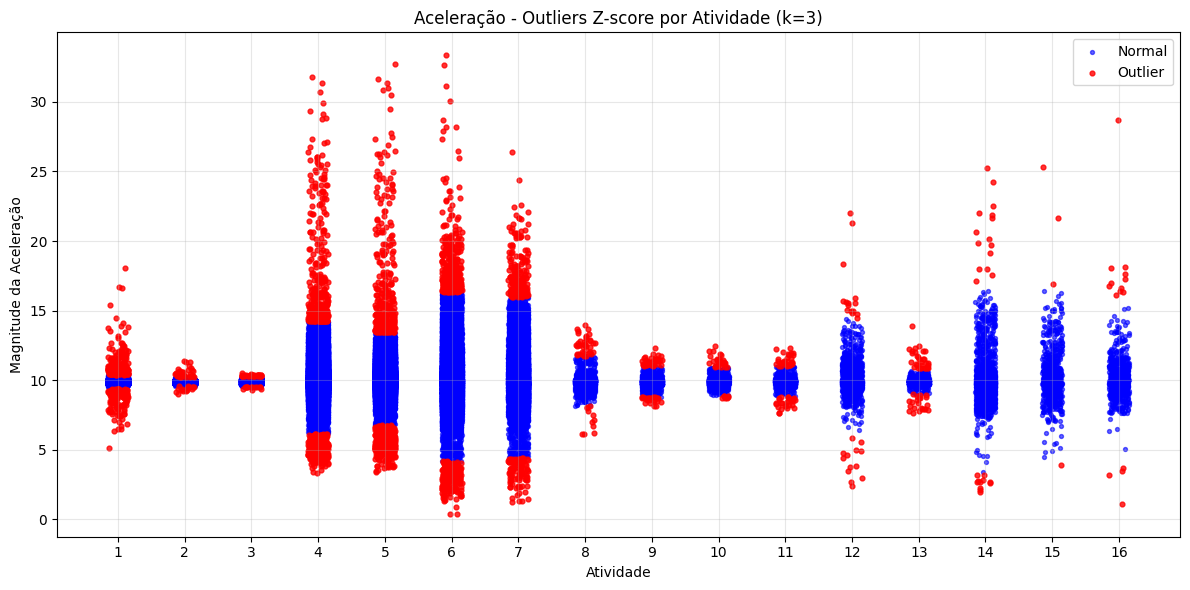

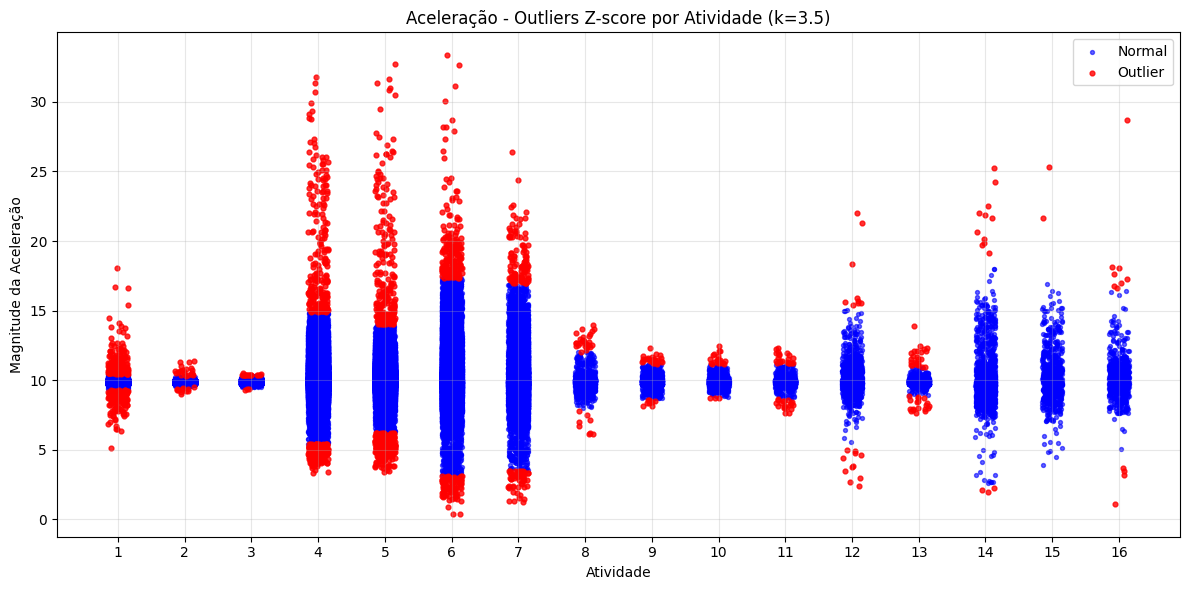

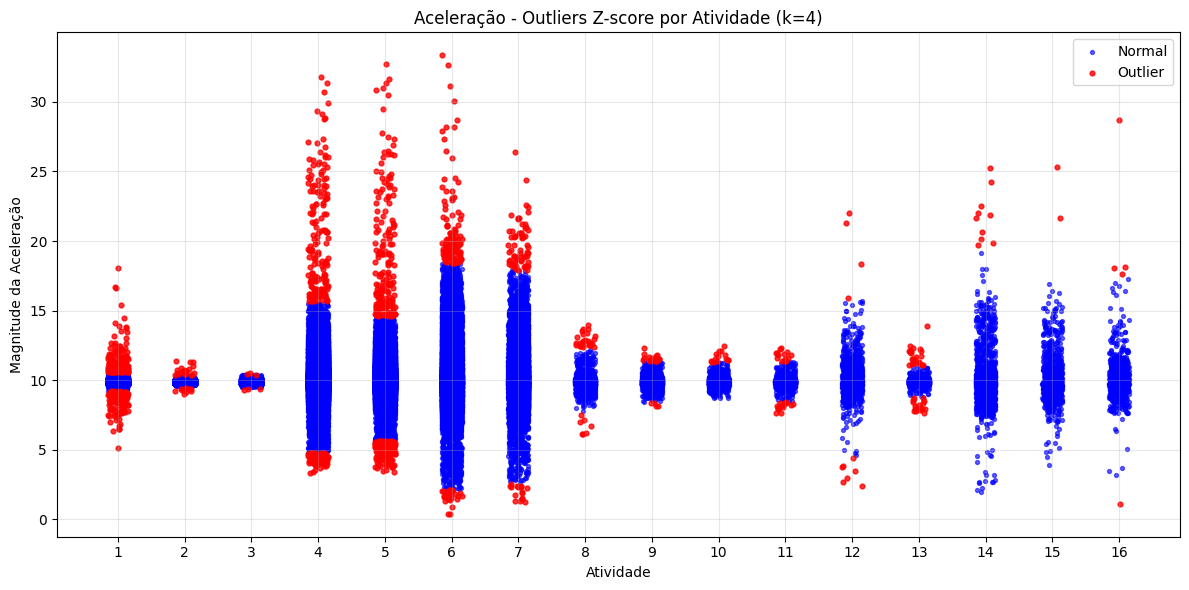

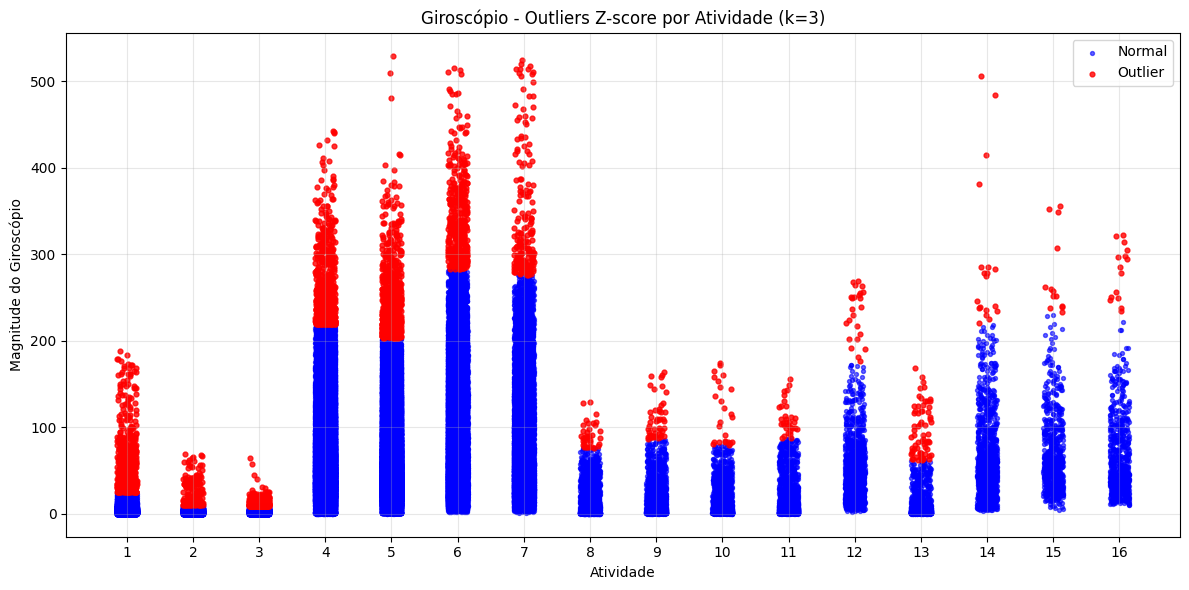

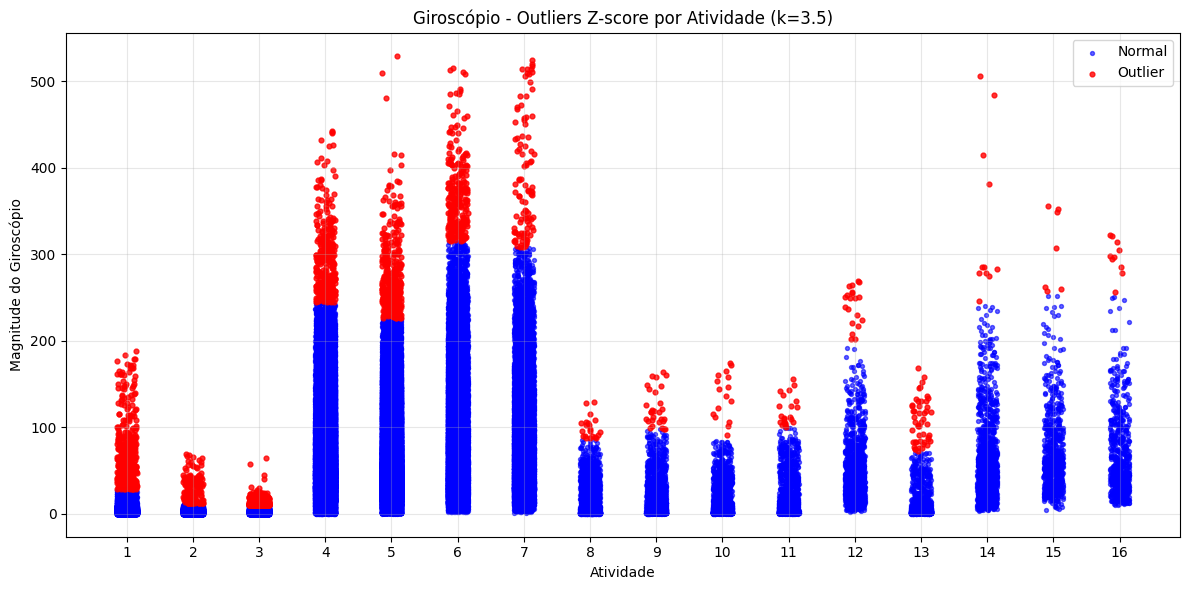

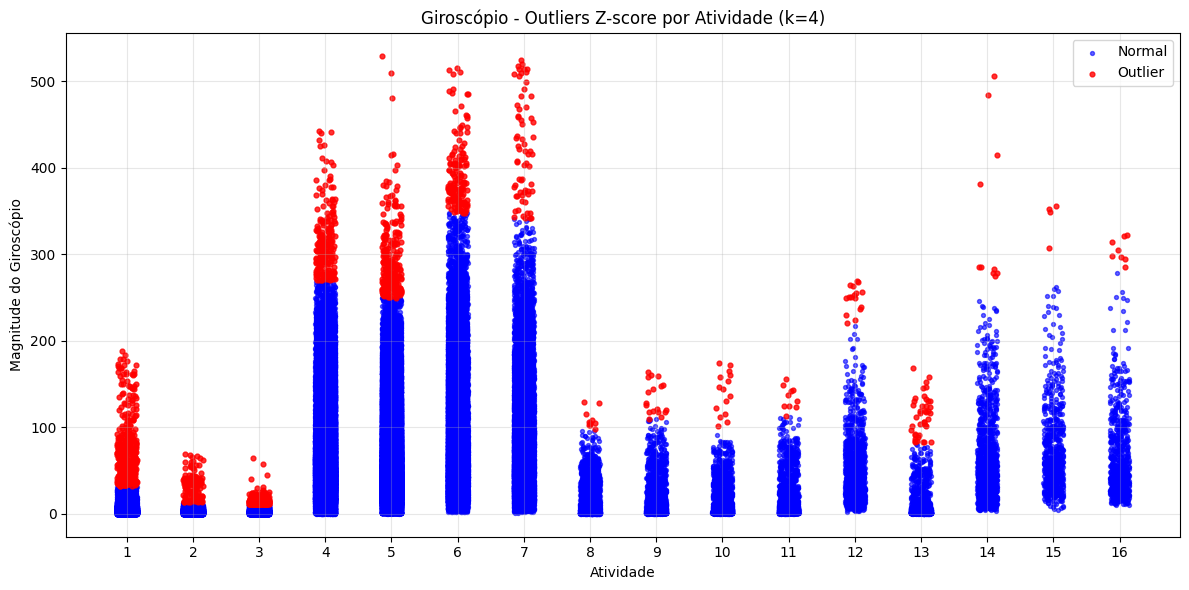

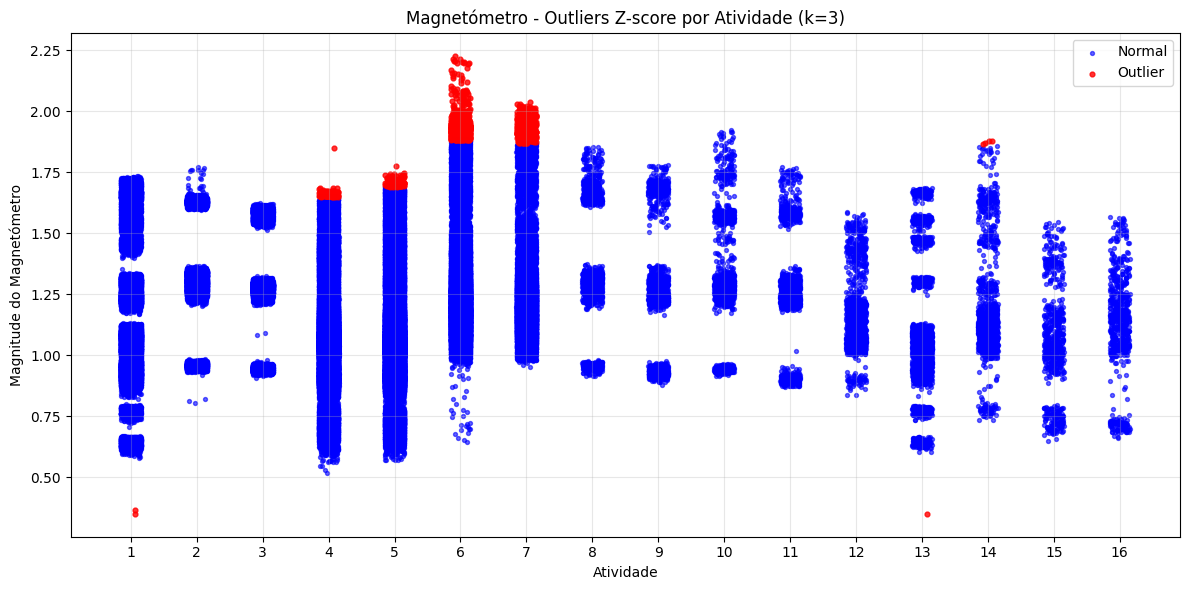

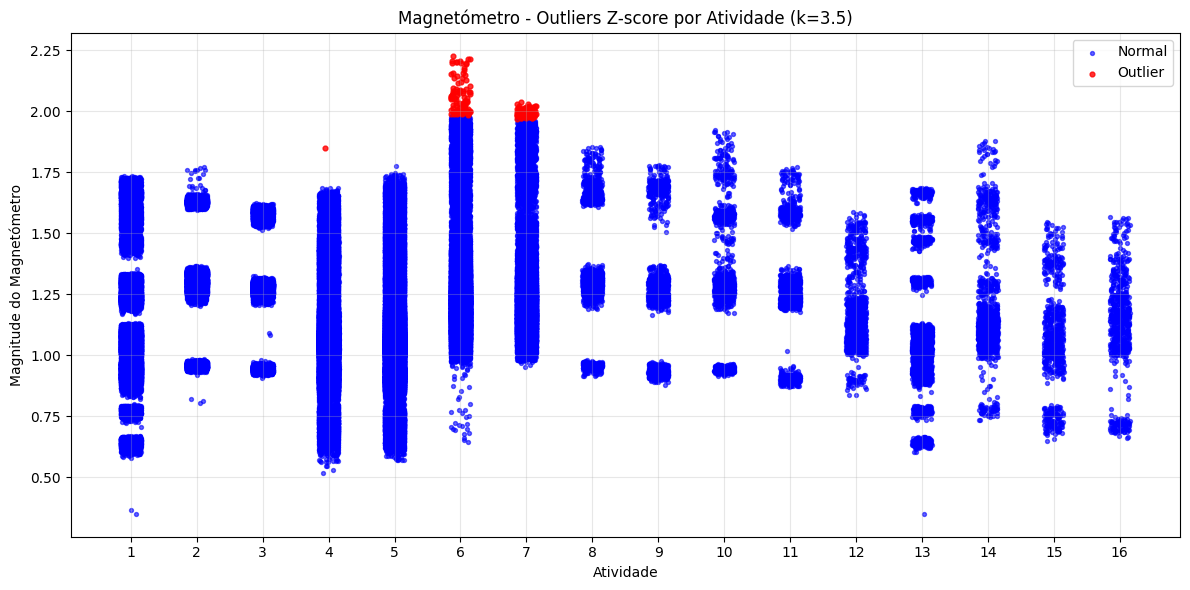

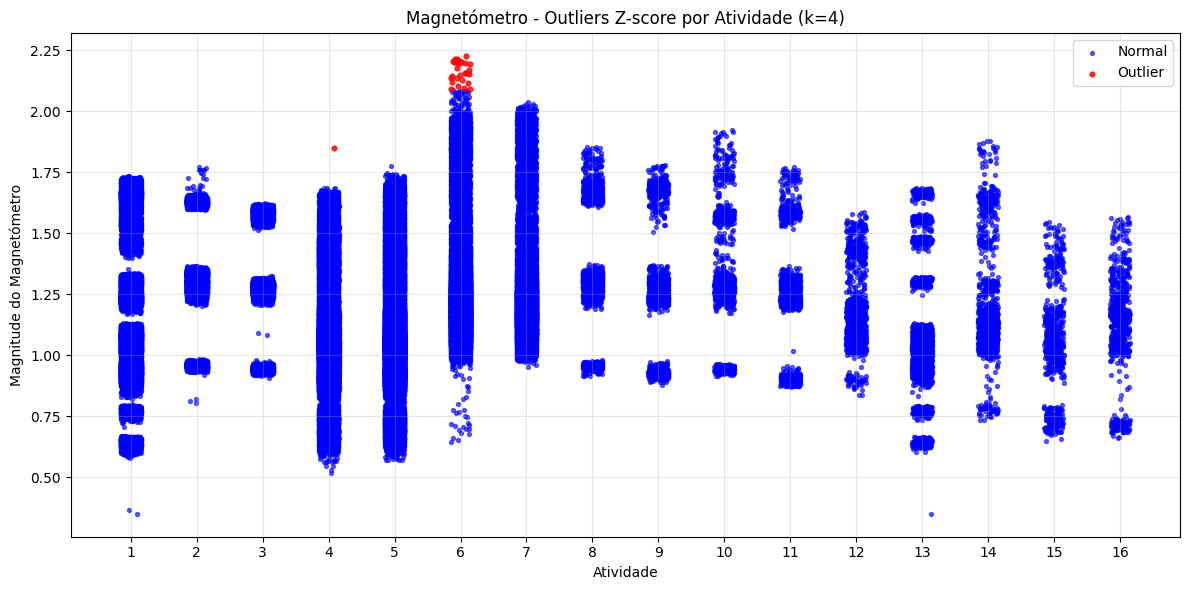

In [7]:
def plot_outliers_zscore(data_array, vector_type='accel', k_values=[3]):

    # Definir coluna inicial e rótulos
    if vector_type == 'accel':
        start_col = 1
        title_base = 'Aceleração'
        ylabel = 'Magnitude da Aceleração'
    elif vector_type == 'gyro':
        start_col = 4
        title_base = 'Giroscópio'
        ylabel = 'Magnitude do Giroscópio'
    elif vector_type == 'mag':
        start_col = 7
        title_base = 'Magnetómetro'
        ylabel = 'Magnitude do Magnetómetro'
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    # Calcular magnitude do vetor
    magnitude = calculate_vector_magnitude(data_array, start_col)
    activities = data_array[:, 11]
    unique_activities = np.sort(np.unique(activities))

    # Criar um gráfico para cada valor de k
    for k in k_values:
        plt.figure(figsize=(12, 6))

        for idx, activity in enumerate(unique_activities):
            mask = activities == activity
            dados_atividade = magnitude[mask]

            # Calcular Z-score por atividade
            media = np.mean(dados_atividade)
            desvio = np.std(dados_atividade)
            if desvio == 0:
                z_scores = np.zeros_like(dados_atividade)
            else:
                z_scores = (dados_atividade - media) / desvio

            # Detectar outliers
            mask_outliers = np.abs(z_scores) > k

            # Adicionar leve jitter no eixo X para visualização
            jitter = np.random.uniform(-0.15, 0.15, size=len(dados_atividade))
            x_vals = np.full_like(dados_atividade, fill_value=activity, dtype=float) + jitter

            # Plotar pontos normais e outliers
            plt.scatter(x_vals[~mask_outliers], dados_atividade[~mask_outliers],
                        color='blue', s=8, alpha=0.6, label='Normal' if idx == 0 else "")
            plt.scatter(x_vals[mask_outliers], dados_atividade[mask_outliers],
                        color='red', s=12, alpha=0.8, label='Outlier' if idx == 0 else "")

        plt.title(f"{title_base} - Outliers Z-score por Atividade (k={k})")
        plt.xlabel("Atividade")
        plt.ylabel(ylabel)
        plt.xticks(unique_activities.astype(int))
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show(block=False)


for v in ['accel', 'gyro', 'mag']:
    plot_outliers_zscore (data, vector_type=v, k_values=[3, 3.5, 4])



## 3.5 Comparação entre IQR vs Z-score

Comparando os métodos, o IQR é mais robusto a distribuições não normais, enquanto o Z-score é sensível a valores extremos e assume simetria. No dataset, observou-se que ambos identificam padrões semelhantes, embora o Z-score tenda a detectar ligeiramente mais outliers em atividades de maior movimento, como 'Walk' e 'Run'.

## 3.6 Implementação do algoritmo K-means

Foi implementado o algoritmo K-means do zero ('k_means'), usando operações vetorizadas do NumPy para ganhar eficiência. O método inicializa centróides aleatoriamente, calcula as distâncias euclidianas entre pontos e centroids de modo a que pontos dentro de cada cluster sejam semelhantes entre si e diferentes dos outros clusters, e atualiza iterativamente até à convergência.

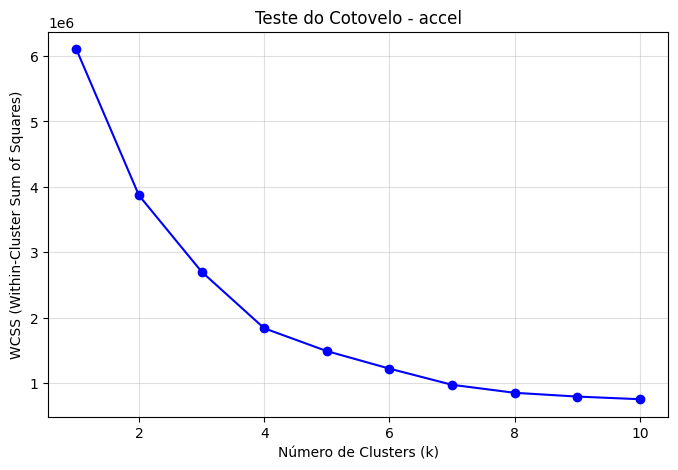

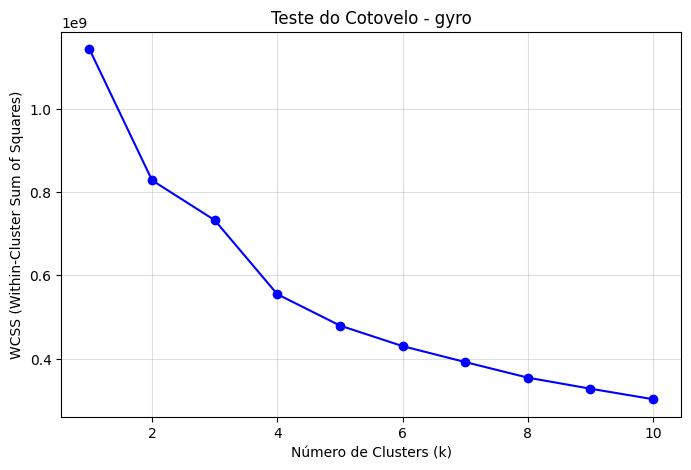

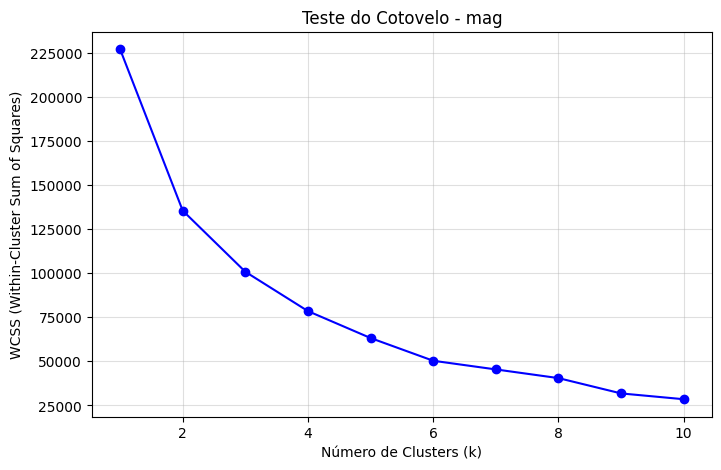


  A executar K-means para accel...
 - K=2: 2 centróides calculados.
 - K=3: 3 centróides calculados.
 - K=4: 4 centróides calculados.
 - K=5: 5 centróides calculados.
 - K=6: 6 centróides calculados.
 - K=7: 7 centróides calculados.
 - K=8: 8 centróides calculados.

  A executar K-means para gyro...
 - K=2: 2 centróides calculados.
 - K=3: 3 centróides calculados.
 - K=4: 4 centróides calculados.
 - K=5: 5 centróides calculados.
 - K=6: 6 centróides calculados.
 - K=7: 7 centróides calculados.
 - K=8: 8 centróides calculados.

  A executar K-means para mag...
 - K=2: 2 centróides calculados.
 - K=3: 3 centróides calculados.
 - K=4: 4 centróides calculados.
 - K=5: 5 centróides calculados.
 - K=6: 6 centróides calculados.
 - K=7: 7 centróides calculados.
 - K=8: 8 centróides calculados.
 Execução do 3.6 concluída!


In [8]:

def k_means(data, n_clusters, max_iters=100, tol=1e-3, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    n_samples = data.shape[0]

    # Inicializar centróides aleatoriamente
    indices = np.random.choice(n_samples, n_clusters, replace=False)
    centroids = data[indices].copy()

    for iteration in range(max_iters):
        # Calcular distâncias (vectorizado)
        distances = np.linalg.norm(data[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
        labels = np.argmin(distances, axis=1)

        # Recalcular centróides
        centroids_old = centroids.copy()
        for k in range(n_clusters):
            cluster_points = data[labels == k]
            if len(cluster_points) > 0:
                centroids[k] = np.mean(cluster_points, axis=0)
            else:
                centroids[k] = data[np.random.choice(n_samples)]

        # Verificar convergência
        if np.linalg.norm(centroids - centroids_old) < tol:
            break

    return labels, centroids

def elbow_method(data_array, vector_type='accel', max_k=10):

    if vector_type == 'accel':
        start_col = 1
    elif vector_type == 'gyro':
        start_col = 4
    elif vector_type == 'mag':
        start_col = 7
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    data_3d = data_array[:, start_col:start_col + 3]
    wcss = []

    for k in range(1, max_k + 1):
        labels, centroids = k_means(data_3d, k, random_state=42)
        distances = np.linalg.norm(data_3d - centroids[labels], axis=1)
        wcss.append(np.sum(distances ** 2))

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k + 1), wcss, 'bo-', markersize=6)
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
    plt.title(f'Teste do Cotovelo - {vector_type}')
    plt.grid(True, alpha=0.4)
    plt.show(block=False)

    return wcss

for v in ['accel', 'gyro', 'mag']:
    elbow_method (data, vector_type=v, max_k=10)
    
for v in ['accel', 'gyro', 'mag']:
    print(f"\n  A executar K-means para {v}...")
    data_3d = data[:, {'accel': 1, 'gyro': 4, 'mag': 7}[v]:{'accel': 1, 'gyro': 4, 'mag': 7}[v] + 3]
    for n_clusters in [2, 3, 4, 5, 6, 7, 8]:
        _, centroids = k_means(data_3d, n_clusters, random_state=42)
        print(f" - K={n_clusters}: {len(centroids)} centróides calculados.")
print(" Execução do 3.6 concluída!")

## 3.7 Deteção de outliers com K-means

A função 'detectar_outliers_kmeans' aplica o K-means no espaço tridimensional (x, y, z) para aceleração, giroscópio e magnetómetro. Os pontos pertencentes aos clusters com menos de 3% dos dados são considerados outliers. A densidade de outliers é calculada e os resultados mostram coerência com os métodos anteriores. Foi também criada a função 'plot_outliers_kmeans_3d' para visualização 3D (não usada neste relatório textual).
Além disso, a função 'comparar_kmeans_vs_zscore' compara quantitativamente os resultados dos dois métodos, mostrando o número de outliers detetados por cada abordagem e o grau de concordância entre ambos, sendo que apenas no giroscópio existe alguma concordância.



K-means com 3 clusters (accel):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(26718), np.int64(1): np.int64(83815), np.int64(2): np.int64(155707)}


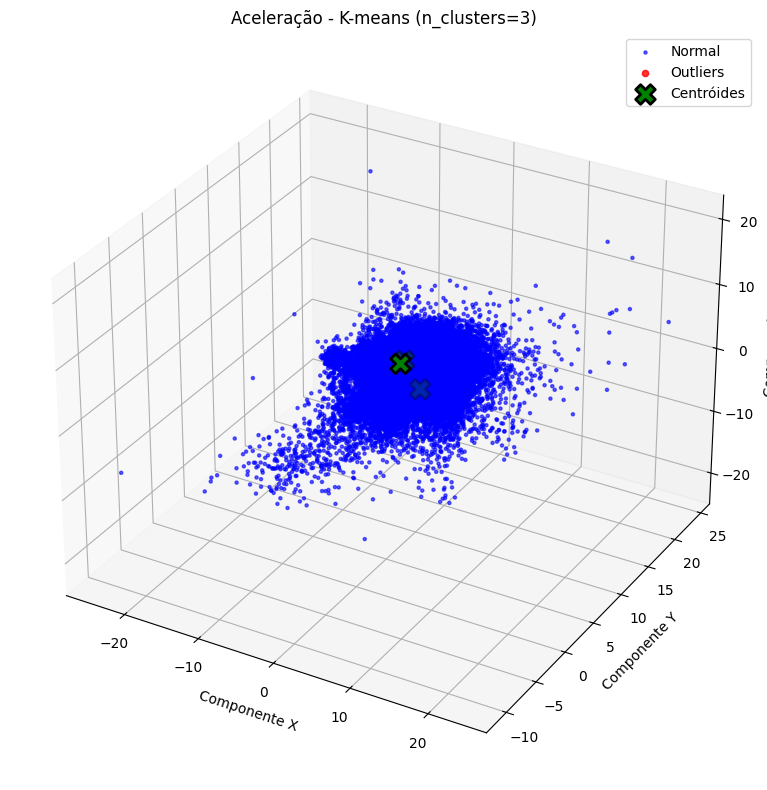


K-means com 5 clusters (accel):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(56474), np.int64(1): np.int64(74529), np.int64(2): np.int64(13124), np.int64(3): np.int64(96499), np.int64(4): np.int64(25614)}


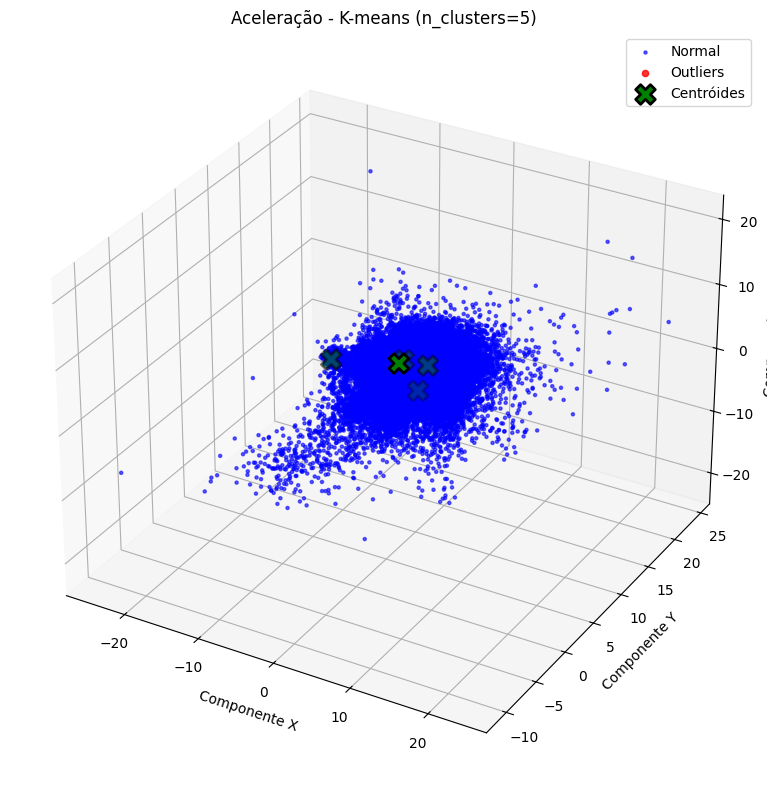


K-means com 6 clusters (accel):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(15010), np.int64(1): np.int64(76926), np.int64(2): np.int64(12882), np.int64(3): np.int64(99725), np.int64(4): np.int64(12972), np.int64(5): np.int64(48725)}


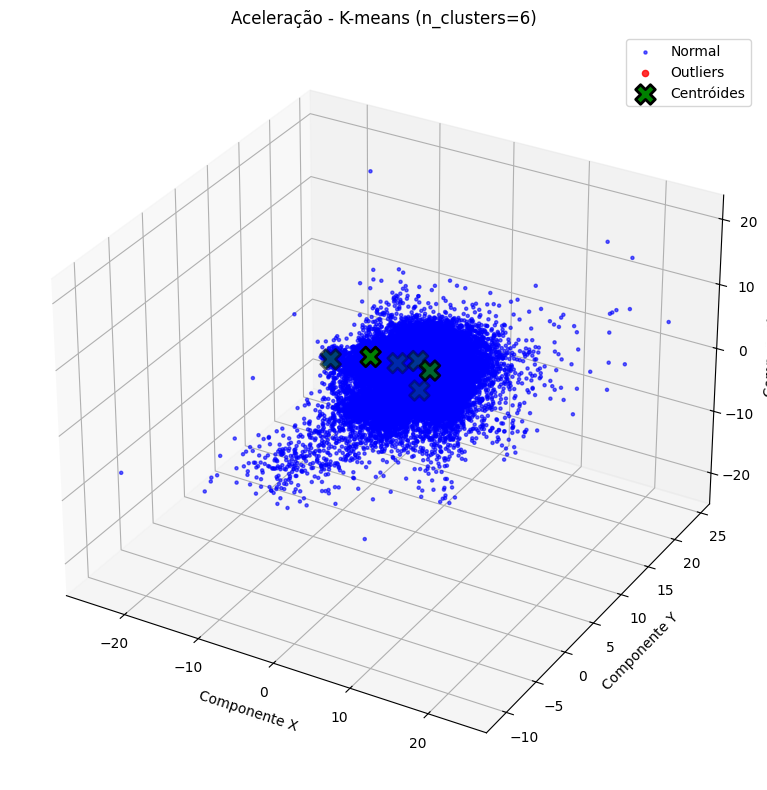


K-means com 3 clusters (gyro):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(13607), np.int64(1): np.int64(201202), np.int64(2): np.int64(51431)}


C:\Users\rodri\AppData\Local\Temp\ipykernel_4008\3298400873.py:110: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


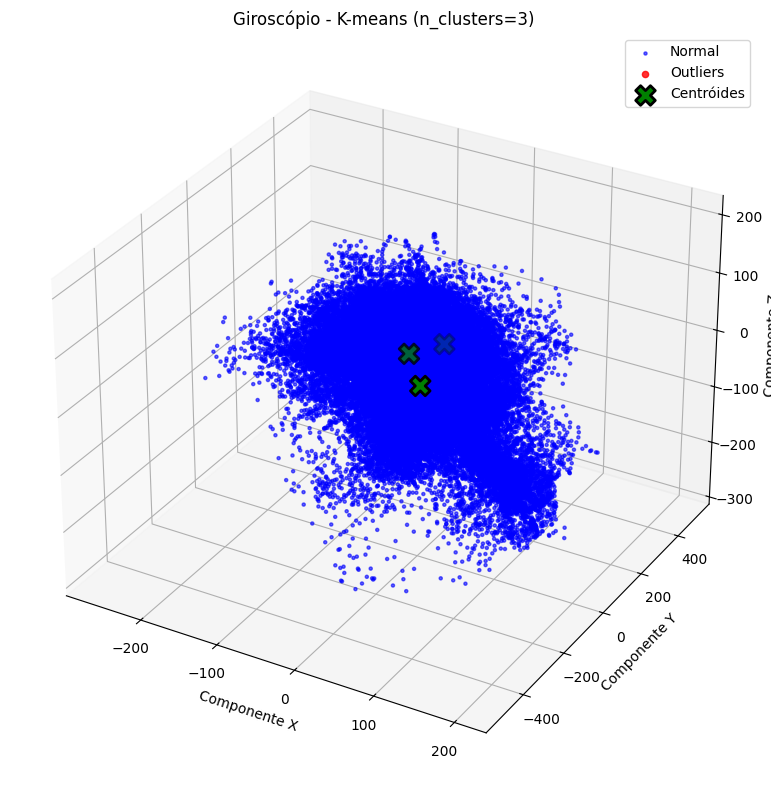


K-means com 5 clusters (gyro):
  Outliers detectados: 5935/266240 (2.23%)
  Distribuição por cluster: {np.int64(0): np.int64(12467), np.int64(1): np.int64(11024), np.int64(2): np.int64(37986), np.int64(3): np.int64(5935), np.int64(4): np.int64(198828)}


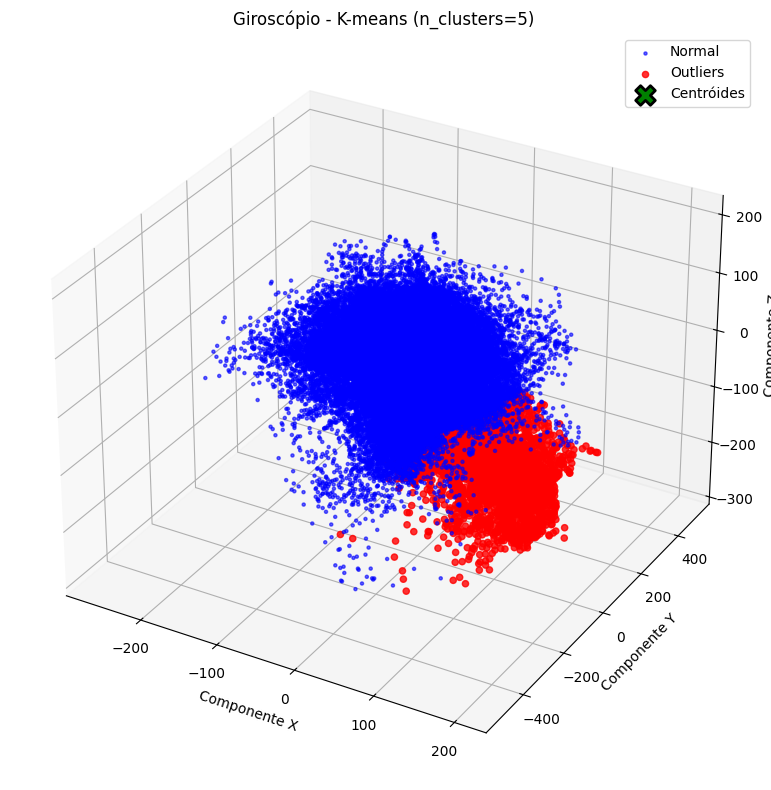


K-means com 6 clusters (gyro):
  Outliers detectados: 6085/266240 (2.29%)
  Distribuição por cluster: {np.int64(0): np.int64(35494), np.int64(1): np.int64(10466), np.int64(2): np.int64(11174), np.int64(3): np.int64(6085), np.int64(4): np.int64(193994), np.int64(5): np.int64(9027)}


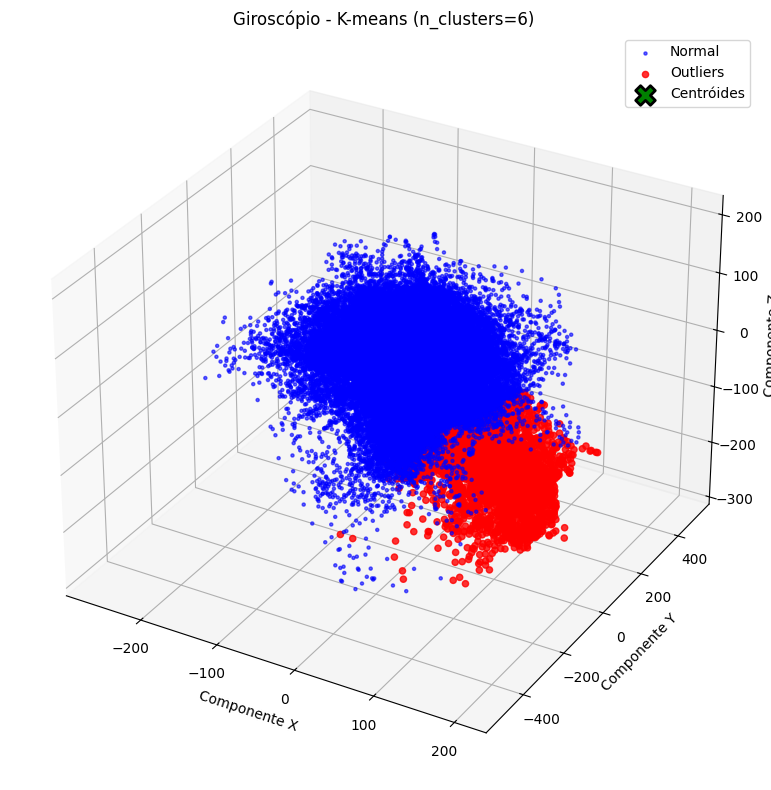


K-means com 3 clusters (mag):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(110695), np.int64(1): np.int64(80756), np.int64(2): np.int64(74789)}


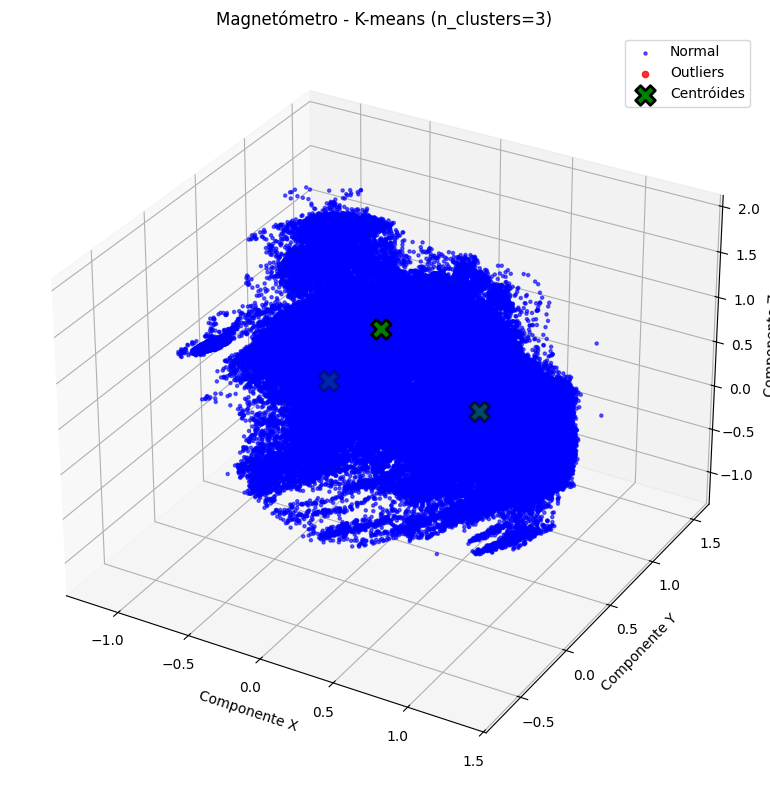


K-means com 5 clusters (mag):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(79944), np.int64(1): np.int64(50323), np.int64(2): np.int64(56693), np.int64(3): np.int64(48880), np.int64(4): np.int64(30400)}


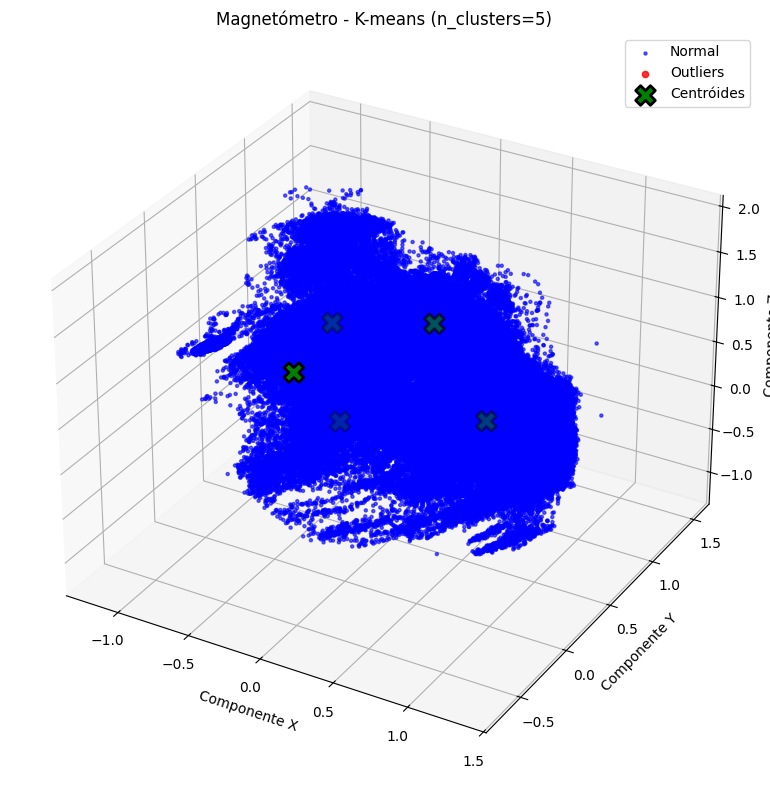


K-means com 6 clusters (mag):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(46679), np.int64(1): np.int64(53458), np.int64(2): np.int64(32872), np.int64(3): np.int64(60582), np.int64(4): np.int64(24490), np.int64(5): np.int64(48159)}


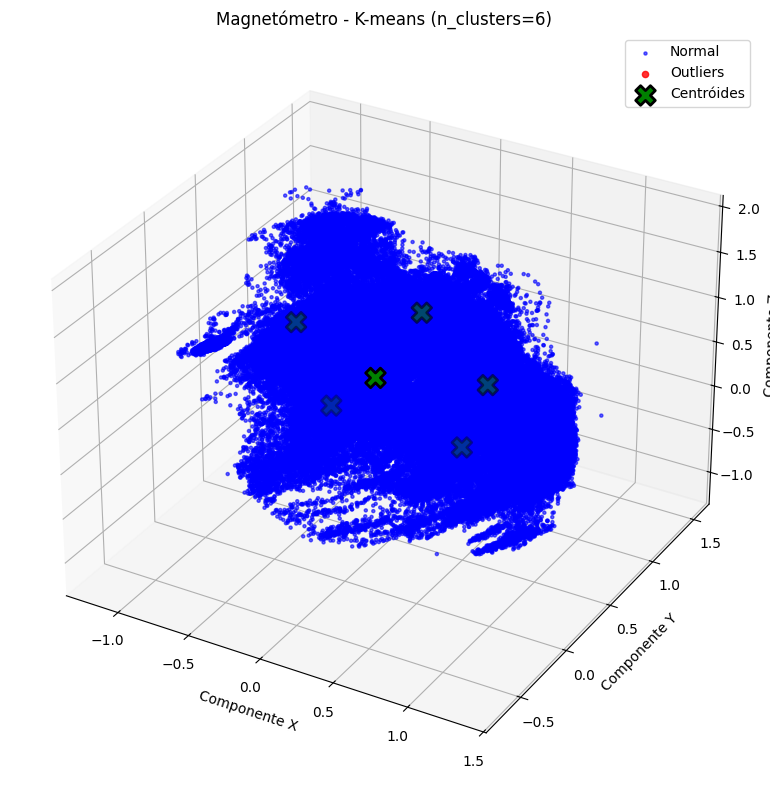

In [9]:
def detectar_outliers_kmeans(data_array, vector_type='accel', n_clusters=4):
    """
    3.7 - Determina outliers usando K-means.
    Pontos em clusters muito pequenos são considerados outliers.

    Parâmetros:
    -----------
    data_array : numpy.ndarray
        Array com todos os dados
    vector_type : str
        Tipo de vetor: 'accel', 'gyro' ou 'mag'
    n_clusters : int
        Número de clusters

    Retorna:
    --------
    outlier_mask : numpy.ndarray
        Máscara booleana indicando outliers
    labels : numpy.ndarray
        Etiquetas de cluster
    """

    if vector_type == 'accel':
        start_col = 1
    elif vector_type == 'gyro':
        start_col = 4
    elif vector_type == 'mag':
        start_col = 7
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    # Extrair os 3 componentes do vetor
    data_3d = data_array[:, start_col:start_col + 3]

    # Aplicar K-means
    labels, centroids = k_means(data_3d, n_clusters, random_state=42)

    # Contar pontos em cada cluster
    unique_labels, counts = np.unique(labels, return_counts=True)

    # Clusters com menos de 3% dos dados são outliers
    threshold = len(data_3d) * 0.03
    outlier_clusters = unique_labels[counts < threshold]

    # Criar máscara de outliers
    outlier_mask = np.isin(labels, outlier_clusters)

    n_outliers = np.sum(outlier_mask)
    density = (n_outliers / len(data_3d)) * 100

    print(f"\nK-means com {n_clusters} clusters ({vector_type}):")
    print(f"  Outliers detectados: {n_outliers}/{len(data_3d)} ({density:.2f}%)")
    print(f"  Distribuição por cluster: {dict(zip(unique_labels, counts))}")

    return outlier_mask, labels, data_3d, centroids

def plot_outliers_kmeans_3d(data_array, vector_type='accel', n_clusters_list=[3, 4, 5, 6]):
    """
    3.7 - Visualiza outliers detectados por K-means em gráficos 3D.
    Compara diferentes números de clusters.

    Parâmetros:
    -----------
    data_array : numpy.ndarray
        Array com todos os dados
    vector_type : str
        Tipo de vetor
    n_clusters_list : list
        Lista de números de clusters a testar
    """

    if vector_type == 'accel':
        title_base = 'Aceleração'
    elif vector_type == 'gyro':
        title_base = 'Giroscópio'
    elif vector_type == 'mag':
        title_base = 'Magnetómetro'
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    for n_clusters in n_clusters_list:
        outlier_mask, labels, data_3d, centroids = detectar_outliers_kmeans(
            data_array, vector_type, n_clusters
        )

        # Criar figura 3D
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        # Plotar pontos normais (azul)
        normal_points = data_3d[~outlier_mask]
        ax.scatter(normal_points[:, 0], normal_points[:, 1], normal_points[:, 2],
                   c='blue', s=5, alpha=0.6, label='Normal')

        # Plotar outliers (vermelho)
        outlier_points = data_3d[outlier_mask]
        ax.scatter(outlier_points[:, 0], outlier_points[:, 1], outlier_points[:, 2],
                   c='red', s=20, alpha=0.8, label='Outliers')

        # Plotar centros dos clusters (verde)
        ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
                   c='green', marker='X', s=200, label='Centróides', edgecolors='black', linewidths=2)

        ax.set_xlabel('Componente X')
        ax.set_ylabel('Componente Y')
        ax.set_zlabel('Componente Z')
        ax.set_title(f'{title_base} - K-means (n_clusters={n_clusters})')
        ax.legend()

        plt.tight_layout()
        plt.show(block=False)

def comparar_kmeans_vs_zscore(data_array, vector_type='accel', n_clusters=5, k=3):
    """
    3.7 - Compara resultados do K-means com Z-score.

    Parâmetros:
    -----------
    data_array : numpy.ndarray
        Array com todos os dados
    vector_type : str
        Tipo de vetor
    n_clusters : int
        Número de clusters para K-means
    k : float
        Parâmetro k para Z-score
    """

    if vector_type == 'accel':
        start_col = 1
        label = 'Aceleração'
    elif vector_type == 'gyro':
        start_col = 4
        label = 'Giroscópio'
    elif vector_type == 'mag':
        start_col = 7
        label = 'Magnetómetro'
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    # Magnitude do vetor
    magnitude = calculate_vector_magnitude(data_array, start_col)

    # Outliers K-means
    outlier_mask_kmeans, _, _, _ = detectar_outliers_kmeans(data_array, vector_type, n_clusters)

    # Outliers Z-score
    media = np.mean(magnitude)
    desvio = np.std(magnitude)
    if desvio > 0:
        z_scores = (magnitude - media) / desvio
        outlier_mask_zscore = np.abs(z_scores) > k
    else:
        outlier_mask_zscore = np.zeros(len(magnitude), dtype=bool)

    # Estatísticas
    n_kmeans = np.sum(outlier_mask_kmeans)
    n_zscore = np.sum(outlier_mask_zscore)
    both = np.sum(outlier_mask_kmeans & outlier_mask_zscore)

    print(f"\n{'=' * 80}")
    print(f"COMPARAÇÃO: K-means vs Z-score ({label})")
    print(f"{'=' * 80}")
    print(f"Outliers K-means (n_clusters={n_clusters}): {n_kmeans} ({n_kmeans / len(magnitude) * 100:.2f}%)")
    print(f"Outliers Z-score (k={k}): {n_zscore} ({n_zscore / len(magnitude) * 100:.2f}%)")
    print(f"Outliers detectados por ambos: {both}")
    print(f"Concordância: {both / max(n_kmeans, n_zscore) * 100:.2f}% (dos detectados por K-means)")
    print(f"{'=' * 80}\n")

    return outlier_mask_kmeans, outlier_mask_zscore


for v in ['accel', 'gyro', 'mag']:
    plot_outliers_kmeans_3d (data, vector_type=v, n_clusters_list=[3, 5, 6])


# 4. Extração e Seleção de Características

## 4.1 Testes de significância

A função 'determinar_significancia_atividade' verifica a normalidade das distribuições de cada atividade com o teste de Kolmogorov–Smirnov. Dependendo do resultado, aplica-se o teste ANOVA (para dados normais) ou Kruskal-Wallis (não paramétrico) para avaliar se há diferenças estatisticamente significativas entre as médias das atividades. Os resultados permitem concluir que as magnitudes variam significativamente entre atividades.

In [10]:
def determinar_significancia_atividade(data_array, vector_type='accel'):
    if vector_type == 'accel':
        start_col = 1
        label = 'Aceleração'
    elif vector_type == 'gyro':
        start_col = 4
        label = 'Giroscópio'
    elif vector_type == 'mag':
        start_col = 7
        label = 'Magnetómetro'
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    magnitude = calculate_vector_magnitude(data_array, start_col)
    activities = data_array[:, 11]
    unique_activities = np.sort(np.unique(activities))
    grupos = [magnitude[activities == a] for a in unique_activities]

    normalidades = []
    for g in grupos:
        if len(g) > 0:
            std_g = np.std(g)
            if std_g == 0:
                normalidades.append(False)
            else:
                stat, p_val = kstest((g - np.mean(g)) / std_g, 'norm')
                normalidades.append(p_val > 0.05)
        else:
            normalidades.append(False)

    normal = all(normalidades)
    if normal:
        stat, p_value = f_oneway(*grupos)
        teste_usado = 'ANOVA (paramétrico)'
    else:
        stat, p_value = kruskal(*grupos)
        teste_usado = 'Kruskal-Wallis (não paramétrico)'

    print(f"\n{'=' * 80}")
    print(f"4.1 - Teste de significância ({label})")
    print(f"{'-' * 80}")
    print(f"Normalidade (todas as atividades normais?): {'Sim' if normal else 'Não'}")
    print(f"Teste usado: {teste_usado}")
    print(f"Estatística = {stat:.4f}, p-valor = {p_value:.6f}")
    print(f"{'=' * 80}\n")
    return {'vector': vector_type, 'teste': teste_usado, 'p_value': p_value, 'normal': normal}

for v in ['accel', 'gyro', 'mag']:
    determinar_significancia_atividade (data, vector_type=v)



4.1 - Teste de significância (Aceleração)
--------------------------------------------------------------------------------
Normalidade (todas as atividades normais?): Não
Teste usado: Kruskal-Wallis (não paramétrico)
Estatística = 2649.1260, p-valor = 0.000000


4.1 - Teste de significância (Giroscópio)
--------------------------------------------------------------------------------
Normalidade (todas as atividades normais?): Não
Teste usado: Kruskal-Wallis (não paramétrico)
Estatística = 189647.6025, p-valor = 0.000000


4.1 - Teste de significância (Magnetómetro)
--------------------------------------------------------------------------------
Normalidade (todas as atividades normais?): Não
Teste usado: Kruskal-Wallis (não paramétrico)
Estatística = 50804.4657, p-valor = 0.000000



## 4.2 Extração de features temporais e espectrais

As rotinas 'extract_temporal_features' e 'extract_spectral_features' calculam, respetivamente, as estatísticas temporais (média, desvio padrão, máximo, mínimo, energia) e as espectrais (potência média e frequência dominante) para cada eixo. Os dados são segmentados em janelas de 5 segundos com 50% de sobreposição ('sliding_window_segments'). Apenas segmentos com uma única atividade são considerados.

In [11]:
def sliding_window_segments(data_array, window_size_sec=5, overlap=0.5, fs=50):
    window_size = int(window_size_sec * fs)
    step_size = int(window_size * (1 - overlap))
    activities = data_array[:, 11]
    segments = []
    for start in range(0, len(data_array) - window_size + 1, step_size):
        end = start + window_size
        window = data_array[start:end]
        if len(np.unique(window[:, 11])) == 1:
            segments.append(window)
    return segments

def extract_temporal_features(segment, vector_type='accel'):
    if vector_type == 'accel':
        start_col = 1
    elif vector_type == 'gyro':
        start_col = 4
    elif vector_type == 'mag':
        start_col = 7
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")
    features = []
    for i in range(start_col, start_col + 3):
        axis_data = segment[:, i]
        features.extend([np.mean(axis_data), np.std(axis_data),
                         np.max(axis_data), np.min(axis_data),
                         np.sum(axis_data ** 2) / len(axis_data)])
    return np.array(features)

def extract_spectral_features(segment, vector_type='accel', fs=50):
    if vector_type == 'accel':
        start_col = 1
    elif vector_type == 'gyro':
        start_col = 4
    elif vector_type == 'mag':
        start_col = 7
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")
    features = []
    for i in range(start_col, start_col + 3):
        axis_data = segment[:, i]
        freqs, psd = welch(axis_data, fs=fs, nperseg=min(256, len(axis_data)))
        features.extend([np.mean(psd), freqs[np.argmax(psd)]])
    return np.array(features)

def extract_feature_vector(segment, vector_type='accel', fs=50):
    return np.concatenate([extract_temporal_features(segment, vector_type),
                           extract_spectral_features(segment, vector_type, fs)])

def extract_feature_set(data_array, vector_type='accel', window_size_sec=5, overlap=0.5, fs=50):
    segments = sliding_window_segments(data_array, window_size_sec, overlap, fs)
    X, y = [], []
    for segment in segments:
        X.append(extract_feature_vector(segment, vector_type, fs))
        y.append(int(segment[0, 11]))
    return np.array(X), np.array(y)


X_accel, y_accel = extract_feature_set(data, vector_type='accel')
X_gyro, y_gyro = extract_feature_set(data, vector_type='gyro')
X_mag, y_mag = extract_feature_set(data, vector_type='mag')
print(f" Features aceleração: {X_accel.shape}")
print(f" Features giroscópio: {X_gyro.shape}")
print(f" Features magnetómetro: {X_mag.shape}")

 Features aceleração: (1898, 21)
 Features giroscópio: (1898, 21)
 Features magnetómetro: (1898, 21)


## 4.3 PCA – Redução de dimensionalidade 

A função 'aplicar_pca' utiliza o método Principal Component Analysis para reduzir a dimensionalidade do vetor de features. O número de componentes é definido de modo a reter 95% da variância total. São apresentadas as variâncias explicadas por cada componente e a variância acumulada. Este processo permite reduzir redundâncias e simplificar o espaço de representação. Nesta função foi inicializado o PCA com a biblioteca sklearn.

In [12]:
def aplicar_pca(feature_set, n_components=0.95, vector_type='accel'):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(feature_set)

    print(f"\n{'=' * 80}")
    print(f"4.3 - PCA ({vector_type})")
    print(f"{'-' * 80}")
    print(f"Número de features originais: {feature_set.shape[1]}")
    print(f"Número de componentes principais: {X_pca.shape[1]}")
    print(f"Variância explicada por cada componente: {pca.explained_variance_ratio_}")
    print(f"Variância acumulada: {np.cumsum(pca.explained_variance_ratio_)}")
    print(f"{'=' * 80}\n")

    return X_pca, pca

aplicar_pca (X_accel, n_components=0.95, vector_type='accel')
aplicar_pca (X_gyro, n_components=0.95, vector_type='gyro')
aplicar_pca (X_mag, n_components=0.95, vector_type='mag')


4.3 - PCA (accel)
--------------------------------------------------------------------------------
Número de features originais: 21
Número de componentes principais: 3
Variância explicada por cada componente: [0.78532306 0.1219578  0.04995959]
Variância acumulada: [0.78532306 0.90728086 0.95724045]


4.3 - PCA (gyro)
--------------------------------------------------------------------------------
Número de features originais: 21
Número de componentes principais: 3
Variância explicada por cada componente: [0.83558354 0.0982806  0.06545505]
Variância acumulada: [0.83558354 0.93386414 0.99931919]


4.3 - PCA (mag)
--------------------------------------------------------------------------------
Número de features originais: 21
Número de componentes principais: 3
Variância explicada por cada componente: [0.69726481 0.18705023 0.09341035]
Variância acumulada: [0.69726481 0.88431505 0.9777254 ]



(array([[-0.58432941, -5.24619022, -3.06859958],
        [ 5.00316673,  0.83757954, -4.55292158],
        [-0.36372103, -5.1380306 , -2.93047238],
        ...,
        [22.19710095, -1.62896982,  4.79576601],
        [22.28419785, -1.665412  ,  4.96916405],
        [21.32500186, -1.2618026 ,  3.05525573]], shape=(1898, 3)),
 PCA(n_components=0.95))

## 4.5 e 4.6 Seleção de features – Fisher Score e ReliefF

O código inclui duas funções adicionais, 'fisher_score' e 'reliefF', implementadas do zero. O Fisher Score avalia a razão entre a variância entre classes e dentro das classes para cada feature, enquanto o ReliefF estima a relevância de uma feature considerando vizinhos próximos da mesma e de outras classes. A função 'selecionar_melhores_features' imprime as 10 features mais relevantes segundo cada método, permitindo comparar as métricas obtidas.

In [13]:
def fisher_score(X, y):
    """
    Calcula o Fisher Score para cada feature.
    X : ndarray (amostras x features)
    y : ndarray (labels)
    """
    classes = np.unique(y)
    n_features = X.shape[1]
    scores = np.zeros(n_features)

    for j in range(n_features):
        feature = X[:, j]
        overall_mean = np.mean(feature)
        num, den = 0, 0
        for c in classes:
            mask = y == c
            class_data = feature[mask]
            if len(class_data) > 1:
                class_mean = np.mean(class_data)
                class_var = np.var(class_data)
                num += len(class_data) * (class_mean - overall_mean) ** 2
                den += len(class_data) * class_var
        scores[j] = num / den if den > 0 else 0

    return scores


def reliefF(X, y, n_neighbors=10):
    """
    Implementação simplificada do algoritmo ReliefF.
    Usa distância euclidiana entre amostras.
    """
    from sklearn.neighbors import NearestNeighbors

    n_samples, n_features = X.shape
    scores = np.zeros(n_features)
    nn = NearestNeighbors(n_neighbors=n_neighbors + 1)
    nn.fit(X)
    neighbors = nn.kneighbors(X, return_distance=False)

    for i in range(n_samples):
        label = y[i]
        hits = X[neighbors[i][1:]][y[neighbors[i][1:]] == label]
        misses = X[neighbors[i][1:]][y[neighbors[i][1:]] != label]

        if len(hits) > 0:
            diff_hit = np.abs(X[i] - np.mean(hits, axis=0))
        else:
            diff_hit = np.zeros(n_features)

        if len(misses) > 0:
            diff_miss = np.abs(X[i] - np.mean(misses, axis=0))
        else:
            diff_miss = np.zeros(n_features)

        scores += diff_miss - diff_hit

    scores = np.maximum(scores, 0)
    return scores


def selecionar_melhores_features(X, y, metodo='fisher', top_n=10):
    """
    4.6 - Identifica as melhores features segundo Fisher Score ou ReliefF.
    """
    if metodo.lower() == 'fisher':
        scores = fisher_score(X, y)
        nome_metodo = "Fisher Score"
    elif metodo.lower() == 'relieff':
        scores = reliefF(X, y)
        nome_metodo = "ReliefF"
    else:
        raise ValueError("Método deve ser 'fisher' ou 'relieff'.")

    top_idx = np.argsort(scores)[::-1][:top_n]

    print(f"\n{'=' * 80}")
    print(f"4.6 - Top {top_n} Features segundo {nome_metodo}")
    print(f"{'-' * 80}")
    for rank, idx in enumerate(top_idx, 1):
        print(f"{rank:2d}. Feature {idx:3d}  |  Score = {scores[idx]:.5f}")
    print(f"{'=' * 80}\n")

    return top_idx, scores


selecionar_melhores_features (X_accel, y_accel, metodo='fisher', top_n=10)
selecionar_melhores_features (X_accel, y_accel, metodo='relieff', top_n=10)



4.6 - Top 10 Features segundo Fisher Score
--------------------------------------------------------------------------------
 1. Feature   6  |  Score = 2.79762
 2. Feature   7  |  Score = 2.66422
 3. Feature   1  |  Score = 1.71423
 4. Feature  11  |  Score = 1.43614
 5. Feature   9  |  Score = 1.07837
 6. Feature   5  |  Score = 0.91866
 7. Feature  17  |  Score = 0.83481
 8. Feature   2  |  Score = 0.52320
 9. Feature  15  |  Score = 0.51594
10. Feature  12  |  Score = 0.47536


4.6 - Top 10 Features segundo ReliefF
--------------------------------------------------------------------------------
 1. Feature   7  |  Score = 151.28140
 2. Feature   3  |  Score = 85.51911
 3. Feature   8  |  Score = 81.27023
 4. Feature   2  |  Score = 76.27912
 5. Feature   9  |  Score = 56.38327
 6. Feature   6  |  Score = 53.75791
 7. Feature  10  |  Score = 47.55506
 8. Feature  13  |  Score = 46.43134
 9. Feature   0  |  Score = 41.05804
10. Feature   1  |  Score = 31.45505



(array([ 7,  3,  8,  2,  9,  6, 10, 13,  0,  1]),
 array([ 41.05804393,  31.45505488,  76.27912325,  85.51910882,
          0.        ,  18.4360336 ,  53.75790636, 151.28139575,
         81.27023053,  56.38326695,  47.55505619,  25.37702351,
         28.72712614,  46.43133613,   0.        ,   0.32829243,
          0.        ,   2.59401331,   0.        ,   0.        ,
          0.        ]))

# Conclusão

O trabalho permitiu compreender todo o processo de análise de sinais multissensoriais aplicados à classificação de atividades humanas. Observou-se que a deteção e tratamento de outliers é crucial para garantir qualidade dos dados e reduzir enviesamentos. Os métodos baseados em estatística (IQR, Z-score) foram complementares aos métodos baseados em clustering (K-means). A extração de features temporais e espectrais revelou-se eficaz para distinguir atividades com diferentes padrões de movimento. O PCA mostrou-se útil para reduzir a dimensionalidade mantendo a maior parte da variância. Por fim, as técnicas de seleção de features (Fisher e ReliefF) destacaram variáveis mais discriminantes, facilitando o desenvolvimento futuro de modelos de classificação supervisionada. Em suma, a pipeline implementada segue boas práticas de ciência de dados e estabelece uma base sólida para trabalhos subsequentes de reconhecimento automático de atividades humanas.

# Meta 2

## 1 Data Integration

### 1.1

A função 'analisar_balanceamento' faz a contagem do número de exemplos para cada atividade considerada, e chegamos à conclusão que não está equilibrado pois há atividades com o dobro de exemplos de outras.

In [14]:
def analisar_balanceamento(X, y):
    """
    1.1 - Conta o número de amostras por atividade (apenas 1 a 7).
    Funciona para qualquer dos vetores: accel, gyro, mag.
    """
    atividades_validas = [1, 2, 3, 4, 5, 6, 7]
    contagem = {a: 0 for a in atividades_validas}

    for label in y:
        if label in contagem:
            contagem[label] += 1

    print("\n=== 1.1 - Balanceamento das Atividades (1 a 7) ===")
    for a, c in contagem.items():
        print(f"Atividade {a}: {c} segmentos")

    return contagem

print("\n=== Teste 1.1 ===")
analisar_balanceamento(X_accel, y_accel)


=== Teste 1.1 ===

=== 1.1 - Balanceamento das Atividades (1 a 7) ===
Atividade 1: 390 segmentos
Atividade 2: 217 segmentos
Atividade 3: 222 segmentos
Atividade 4: 347 segmentos
Atividade 5: 362 segmentos
Atividade 6: 231 segmentos
Atividade 7: 106 segmentos


{1: 390, 2: 217, 3: 222, 4: 347, 5: 362, 6: 231, 7: 106}

### 1.2

A função 'aplicar_smote' implementa uma versão simplificada do método SMOTE. Esta função converte X e y em arrays NumPy, filtra as atividades e gera novas amostras sintéticas para a atividade, de modo a diminuir o desiquilíbrio do dataset.

In [15]:
import random
from sklearn.neighbors import NearestNeighbors

def aplicar_smote(X, y, atividade, k=5, n_novos=10):
    
    X = np.array(X)
    y = np.array(y)

    # Filtrar apenas a atividade específica
    mask = y == atividade
    X_min = X[mask]

    if len(X_min) == 0:
        raise ValueError(f"Nenhuma amostra da atividade {atividade} disponível para SMOTE.")

    # kNN
    nn = NearestNeighbors(n_neighbors=min(k, len(X_min)))
    nn.fit(X_min)
    vizinhos = nn.kneighbors(return_distance=False)

    novos = []

    for _ in range(n_novos):
        # Escolher amostra base
        idx = random.randint(0, len(X_min) - 1)
        base = X_min[idx]

        # Escolher vizinho
        nn_idx = random.choice(vizinhos[idx])
        neigh = X_min[nn_idx]

        # Geração SMOTE
        alpha = np.random.rand()
        sint = base + alpha * (neigh - base)
        novos.append(sint)

    novos = np.array(novos)
    novos_labels = np.full(n_novos, atividade)

    print(f"\nGeradas {n_novos} novas amostras sintéticas para a atividade {atividade}.")

    return novos, novos_labels

print("\n=== Teste 1.2 ===")
aplicar_smote(X_accel, y_accel, atividade=4, k=5, n_novos=3)


=== Teste 1.2 ===

Geradas 3 novas amostras sintéticas para a atividade 4.


(array([[ 3.94445066e-02,  1.87249801e+00,  5.62940777e+00,
         -1.34895542e+01,  3.51443934e+00,  9.62167670e+00,
          1.83842590e+00,  1.39658013e+01,  3.18257432e+00,
          9.59708808e+01, -2.35663708e+00,  2.11857568e+00,
          3.85469217e+00, -1.48833074e+01,  1.00598646e+01,
          1.23713071e-01,  8.19680103e-01,  7.34347038e-02,
          1.62746001e+00,  1.88451171e-01,  6.00000000e-01],
        [-2.48669359e-01,  2.23639313e+00,  7.05380030e+00,
         -1.70997736e+01,  5.07857048e+00,  9.59307307e+00,
          2.05167724e+00,  1.39170394e+01,  3.34109576e+00,
          9.62390094e+01, -2.64185471e+00,  2.62310077e+00,
          4.42559110e+00, -1.62548247e+01,  1.38771351e+01,
          1.76695804e-01,  9.44854961e-01,  1.79927471e-01,
          1.65747583e+00,  3.00925296e-01,  6.00000000e-01],
        [ 2.13393286e+00,  1.13582120e+00,  7.48652285e+00,
          3.56389219e-01,  5.87806192e+00,  9.49844183e+00,
          1.02031216e+00,  1.19540112e

### 1.3

A função 'visualizar_sinteticos_part3' tem como objetivo gerar e visualizar amostras sintéticas de uma atividade específica, utilizando apenas os dados do participante 3 e representando-os num gráfico 2D. Primeiro, a função chama o método 'aplicar_smote' para criar novas amostras da atividade selecionada, depois reduz os dados às duas primeiras features e projeta os dados num gráfico, onde se podem visualizar as amostras reais e sintéticas.


=== Teste 1.3 ===

Geradas 3 novas amostras sintéticas para a atividade 4.


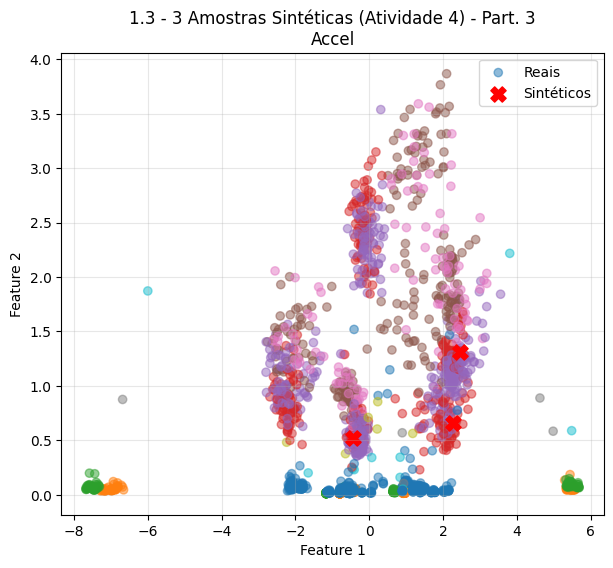


Exibido gráfico das novas amostras sintéticas.


(array([[ 2.46355316e+00,  1.31137991e+00,  5.51080000e+00,
         -8.31640000e-01,  7.78955089e+00,  9.48108696e+00,
          1.24584928e+00,  1.49720000e+01,  5.81724818e+00,
          9.14436443e+01,  4.15118592e-01,  1.87603710e+00,
          5.46877886e+00, -2.47866228e+00,  3.69948841e+00,
          6.35025682e-02,  6.00000000e-01,  5.38728667e-02,
          1.40430149e+00,  1.29580546e-01,  6.00000000e-01],
        [-4.35245677e-01,  5.20680081e-01,  1.01702795e+00,
         -1.73354284e+00,  4.61012694e-01,  9.47822690e+00,
          7.94624947e-01,  1.27870000e+01,  7.64477763e+00,
          9.04683419e+01,  3.07193370e+00,  1.03807419e+00,
          5.66190000e+00,  5.78960754e-01,  1.05145931e+01,
          1.10941241e-02,  1.71061688e+00,  2.33082522e-02,
          3.42123376e+00,  4.15068416e-02,  1.20000000e+00],
        [ 2.27384200e+00,  6.63470055e-01,  4.15509846e+00,
          6.84197837e-01,  5.62848721e+00,  9.17430669e+00,
          8.39672310e-01,  1.13771730e

In [16]:
def visualizar_sinteticos_part3(X, y, atividade=4, n_sint=3, titulo=""):
    
    novos, novos_labels = aplicar_smote(X, y, atividade, k=5, n_novos=n_sint)

    # Apagar tudo exceto as 2 primeiras features
    X_vis = X[:, :2]
    novos_vis = novos[:, :2]

    # Plot
    plt.figure(figsize=(7, 6))

    # Dados reais
    plt.scatter(X_vis[:, 0], X_vis[:, 1],
                c=y, cmap='tab10', alpha=0.5, label='Reais')

    # Dados sintéticos
    plt.scatter(novos_vis[:, 0], novos_vis[:, 1],
                c='red', marker='X', s=120, label='Sintéticos')

    plt.title(f"1.3 - 3 Amostras Sintéticas (Atividade {atividade}) - Part. 3\n{titulo}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\nExibido gráfico das novas amostras sintéticas.")

    return novos, novos_labels

print("\n=== Teste 1.3 ===")
visualizar_sinteticos_part3(X_accel, y_accel, atividade=4, n_sint=3, titulo="Accel")

## 2  Embedding Features

### 2.1

A função 'load_embedding_model' é usada para carregar e preparar o modelo HARNet5. Em 'acc_segmentation_for_embeddings', os dados são divididos em segmentos de 5 segundos, e reamostrados para 30Hz através da função 'resample_segment_to_30hz' garantindo que todos têm a mesma duração temporal exigida pelo modelo. Por fim, a função 'create_embeddings_dataset' devolve um dataset de embeddings que vai ser usado nos pontos seguintes.

In [17]:
import torch

def load_embedding_model():
    print("A carregar modelo HARNet5")
    repo = 'OxWearables/ssl-wearables'
    model = torch.hub.load(repo, 'harnet5', class_num=5, pretrained=True)
    encoder = model.feature_extractor
    encoder.eval()
    encoder.to("cpu")
    return encoder

# ---------- Segmentação ACC ----------
def acc_segmentation_for_embeddings(data):
    TIMESTAMP_COL = 10
    MIN_SEGMENT_SIZE = 20
    fs_in_hz = 51.5
    win_size = 5000

    start_time = data[0, TIMESTAMP_COL]
    end_time = start_time + win_size

    activities = []
    segments = []

    while end_time < data[-1, TIMESTAMP_COL]:
        mask = (data[:, TIMESTAMP_COL] >= start_time) & (data[:, TIMESTAMP_COL] < end_time)

        if np.sum(mask) > MIN_SEGMENT_SIZE and np.all(data[mask, -1] == data[mask, -1][0]):
            acc_xyz = data[mask, 1:4]
            activity = int(data[mask, -1][0])

            segments.append(acc_xyz)
            activities.append(activity)

        start_time = end_time - win_size/2
        end_time = start_time + win_size

    return segments, activities


# ---------- Reamostragem para 30 Hz ----------
def resample_segment_to_30hz(segment, fs_in=51.5):
    win_size = 5
    fs_target = 30.0

    t_in = np.arange(segment.shape[0]) / fs_in
    t_out = np.arange(0, win_size, 1.0 / fs_target)

    res = np.zeros((len(t_out), 3), dtype=np.float32)
    for i in range(3):
        res[:, i] = np.interp(t_out, t_in, segment[:, i])
    return res


# ---------- Criar dataset de embeddings ----------
def create_embeddings_dataset(data):

    encoder = load_embedding_model()

    print("A segmentar ACC...")
    segments, activities = acc_segmentation_for_embeddings(data)

    print(f"Segmentos obtidos: {len(segments)}")

    # Reamostrar cada segmento
    print("A reamostrar para 30 Hz...")
    resampled = [resample_segment_to_30hz(seg) for seg in segments]

    # Preparar tensor para o modelo (N, C, T)
    x_all = np.transpose(np.array(resampled), (0, 2, 1))  # → (N, 3, T)

    embeddings_list = []
    batch_size = 16

    print("A gerar embeddings...")
    with torch.no_grad():
        for i in range(0, x_all.shape[0], batch_size):
            xb = torch.from_numpy(x_all[i:i+batch_size]).float()
            eb = encoder(xb)
            embeddings_list.append(eb.cpu().numpy())

    X_emb = np.concatenate(embeddings_list, axis=0)
    y_emb = np.array(activities)

    print(f"Embedding dataset criado: {X_emb.shape}")
    print(f"Labels: {y_emb.shape}")

    return X_emb, y_emb

## 3

#### 3.1

Nesta parte do código, é implementada uma pipeline completa de carregamento, processamento e preparação dos dados para posterior utilização em modelos de classificação. São carregados os dados dos 15 participantes através da função 'load_participant_data' e gera um conjunto de features e outro de embeddings para cada um. Após percorrer todos os participantes, o código concatena as listas individuais, formando dois datasets completos: um dataset de features e um dataset de embeddings. Por fim, é realizado o split dentro do sujeito (60-20-20%).

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split

print("🚀 A iniciar carregamento seguro (sem estragar variáveis anteriores)...")

# --- 1. INICIALIZAÇÃO ---
X_features_list = []
y_features_list = []
subjects_list_feats = []  # Lista de sujeitos para as Features

X_embeddings_list = []
y_embeddings_list = []
subjects_list_embs = []   # Lista de sujeitos para os Embeddings

# --- 2. LOOP DE CARREGAMENTO ---
for part_id in range(0, 15):
    print(f"📦 A processar Participante {part_id}...", end=" ")
    
    try:
        # USA A TUA FUNÇÃO ORIGINAL (Mas guarda numa variável temporária)
        data_temp = load_participant_data(part_id)
        
        if len(data_temp) == 0: 
            print("Vazio.")
            continue 

        # --- A. FEATURES MANUAIS ---
        # Extrair features deste participante específico
        X_accel, y_accel = extract_feature_set(data_temp, vector_type='accel')
        
        # Filtro atividades <= 7
        mask_f = y_accel <= 7
        X_accel = X_accel[mask_f]
        y_accel = y_accel[mask_f]
        
        if len(X_accel) > 0:
            X_features_list.append(X_accel)
            y_features_list.append(y_accel)
            # Criar sujeitos baseados no tamanho das Features
            subjects_list_feats.append(np.full(len(y_accel), part_id))
        
        # --- B. EMBEDDINGS ---
        X_emb, y_emb = create_embeddings_dataset(data_temp)
        
        if len(X_emb) > 0:
            X_embeddings_list.append(X_emb)
            y_embeddings_list.append(y_emb)
            # Criar sujeitos baseados no tamanho dos Embeddings
            subjects_list_embs.append(np.full(len(y_emb), part_id))
            
        print("OK.")

    except Exception as e:
        print(f"❌ Erro: {e}")

# --- 3. CONCATENAÇÃO FINAL ---
# Para Features
if len(X_features_list) > 0:
    X_features_all = np.concatenate(X_features_list, axis=0)
    y_features_all = np.concatenate(y_features_list, axis=0)
    subjects_all_feats = np.concatenate(subjects_list_feats, axis=0) 

    # Para Embeddings
    X_embeddings_all = np.concatenate(X_embeddings_list, axis=0)
    y_embeddings_all = np.concatenate(y_embeddings_list, axis=0)
    subjects_all_embs = np.concatenate(subjects_list_embs, axis=0) 
    
    # Garantir 2D se vier 3D
    if X_embeddings_all.ndim > 2:
        X_embeddings_all = X_embeddings_all.reshape(X_embeddings_all.shape[0], -1)

    print("\n✅ DATASET CARREGADO:")
    print(f"   Features:   X={X_features_all.shape}, Sujeitos={subjects_all_feats.shape}")
    print(f"   Embeddings: X={X_embeddings_all.shape}, Sujeitos={subjects_all_embs.shape}")
else:
    print("❌ Erro: Nenhum dado foi carregado.")


# ==============================================================================
# 3.1 - SPLIT WITHIN-SUBJECT (60-20-20)
# ==============================================================================

def split_within_subject(X, y):
    # 1. Separar 60% para Treino e 40% para Temp (Validação + Teste)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.4, random_state=42, stratify=y
    )
    
    # 2. Dividir os 40% restantes em metades iguais (20% total cada)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )
    
    return X_train, y_train, X_val, y_val, X_test, y_test

if len(X_features_list) > 0:
    print("\n✂️ A executar Split 3.1...")

    # Aplicar às Features Manuais
    Xf_train, yf_train, Xf_val, yf_val, Xf_test, yf_test = split_within_subject(X_features_all, y_features_all)

    # Aplicar aos Embeddings
    Xe_train, ye_train, Xe_val, ye_val, Xe_test, ye_test = split_within_subject(X_embeddings_all, y_embeddings_all)

    print(f"Features: Treino={len(yf_train)}, Val={len(yf_val)}, Teste={len(yf_test)}")
    print(f"Embeddings: Treino={len(ye_train)}, Val={len(ye_val)}, Teste={len(ye_test)}")

🚀 A iniciar carregamento seguro (sem estragar variáveis anteriores)...
📦 A processar Participante 0... A carregar modelo HARNet5


Using cache found in C:\Users\rodri/.cache\torch\hub\OxWearables_ssl-wearables_main


131 Weights loaded
A segmentar ACC...
Segmentos obtidos: 351
A reamostrar para 30 Hz...
A gerar embeddings...
Embedding dataset criado: (351, 512, 1)
Labels: (351,)
OK.
📦 A processar Participante 1... A carregar modelo HARNet5


Using cache found in C:\Users\rodri/.cache\torch\hub\OxWearables_ssl-wearables_main


131 Weights loaded
A segmentar ACC...
Segmentos obtidos: 350
A reamostrar para 30 Hz...
A gerar embeddings...
Embedding dataset criado: (350, 512, 1)
Labels: (350,)
OK.
📦 A processar Participante 2... A carregar modelo HARNet5


...

131 Weights loaded
A segmentar ACC...
Segmentos obtidos: 335
A reamostrar para 30 Hz...
A gerar embeddings...
Embedding dataset criado: (335, 512, 1)
Labels: (335,)
OK.
📦 A processar Participante 13... A carregar modelo HARNet5


Using cache found in C:\Users\rodri/.cache\torch\hub\OxWearables_ssl-wearables_main


131 Weights loaded
A segmentar ACC...
Segmentos obtidos: 347
A reamostrar para 30 Hz...
A gerar embeddings...
Embedding dataset criado: (347, 512, 1)
Labels: (347,)
OK.
📦 A processar Participante 14... A carregar modelo HARNet5


Using cache found in C:\Users\rodri/.cache\torch\hub\OxWearables_ssl-wearables_main


131 Weights loaded
A segmentar ACC...
Segmentos obtidos: 340
A reamostrar para 30 Hz...
A gerar embeddings...
Embedding dataset criado: (340, 512, 1)
Labels: (340,)
OK.

✅ DATASET CARREGADO:
   Features:   X=(27628, 21), Sujeitos=(27628,)
   Embeddings: X=(5130, 512), Sujeitos=(5130,)

✂️ A executar Split 3.1...
Features: Treino=16576, Val=5526, Teste=5526
Embeddings: Treino=3078, Val=1026, Teste=1026


### 3.2

A função 'split_between_subjects' divide aleatoriamente os dados por participantes (9 treino, 3 validação, 3 teste). A função cria então máscaras booleanas que selecionam apenas as amostras pertencentes aos sujeitos definidos para cada conjunto. No final, são retornados os vetores X e y já separados nas três partições (treino, validação, teste), tanto para o dataset de features manuais como para o dataset de embeddings, e é imprimida a informação acerca dos participantes selecionados para cada grupo, assim como a dimensão final de cada dataset

In [19]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

# ==============================================================================
# 3.2 - Estratégia "Between-Subject" (CORRIGIDA)
# ==============================================================================

def split_between_subjects(X, y, subjects, random_state=42):

    unique_subs = np.unique(subjects)
    np.random.seed(random_state)
    shuffled_subs = np.random.permutation(unique_subs)
    
    # Definir grupos (9 Treino, 3 Validação, Resto Teste)
    # Ajuste de segurança caso haja menos participantes
    n_train = 9
    n_val = 3
    if len(unique_subs) < 12:
        n_train = int(len(unique_subs) * 0.6)
        n_val = int(len(unique_subs) * 0.2)
    
    train_subs = shuffled_subs[:n_train]
    val_subs = shuffled_subs[n_train : n_train + n_val]
    test_subs = shuffled_subs[n_train + n_val :]
    
    print(f"  > Participantes ({len(unique_subs)}): Treino={train_subs} | Val={val_subs} | Teste={test_subs}")
    
    # Criar máscaras booleanas
    mask_train = np.isin(subjects, train_subs)
    mask_val   = np.isin(subjects, val_subs)
    mask_test  = np.isin(subjects, test_subs)
    
    return X[mask_train], y[mask_train], X[mask_val], y[mask_val], X[mask_test], y[mask_test]

print("🚀 A executar Split 3.2 (Between-Subjects)...")

# A) FEATURES MANUAIS (Usa 'subjects_all_feats')
# -----------------------------------------------------------
if 'subjects_all_feats' in locals():
    print("\n--- A. FEATURES DATASET ---")
    Xf_train_b, yf_train_b, Xf_val_b, yf_val_b, Xf_test_b, yf_test_b = split_between_subjects(
        X_features_all, y_features_all, subjects_all_feats
    )
    print(f"✅ Features: Treino={len(yf_train_b)}, Val={len(yf_val_b)}, Teste={len(yf_test_b)}")
else:
    print("❌ Erro: 'subjects_all_feats' não existe. Corre o carregamento primeiro.")

# B) EMBEDDINGS (Usa 'subjects_all_embs')
# -----------------------------------------------------------
if 'subjects_all_embs' in locals():
    print("\n--- B. EMBEDDINGS DATASET ---")
    Xe_train_b, ye_train_b, Xe_val_b, ye_val_b, Xe_test_b, ye_test_b = split_between_subjects(
        X_embeddings_all, y_embeddings_all, subjects_all_embs
    )
    print(f"✅ Embeddings: Treino={len(ye_train_b)}, Val={len(ye_val_b)}, Teste={len(ye_test_b)}")
else:
    print("❌ Erro: 'subjects_all_embs' não existe. Corre o carregamento primeiro.")

🚀 A executar Split 3.2 (Between-Subjects)...

--- A. FEATURES DATASET ---
  > Participantes (15): Treino=[ 9 11  0 13  5  8  2  1 14] | Val=[ 4  7 10] | Teste=[12  3  6]
✅ Features: Treino=16586, Val=5410, Teste=5632

--- B. EMBEDDINGS DATASET ---
  > Participantes (15): Treino=[ 9 11  0 13  5  8  2  1 14] | Val=[ 4  7 10] | Teste=[12  3  6]
✅ Embeddings: Treino=3378, Val=734, Teste=1018


### 3.3

Na estratégia within-subject (3.1), cada participante contribui com dados para treino, validação e teste. Isto faz com que o modelo seja avaliado em segmentos de pessoas que já viu durante o treino. O resultado tende a ser otimista, porque o modelo beneficia de padrões específicos de cada participante (movimento, postura, ruído dos sensores), que se repetem nos três conjuntos.

Na estratégia between-subject (3.2), cada participante pertence apenas a um dos conjuntos. Assim, o modelo é testado em pessoas totalmente novas, o que exige uma verdadeira capacidade de generalização e reflete melhor o uso real do sistema.

Por isso, a estratégia between-subject fornece uma estimativa mais fiável do desempenho em novos utilizadores, enquanto a estratégia within-subject tende a sobrestimar a performance.

### 3.4

Na alínea 3.4, preparam-se três cenários distintos do dataset após a divisão em treino, validação e teste: (i) All Features, com todas as features normalizadas pelo treino; (ii) PCA, reduzindo a dimensionalidade mantendo 90% da variância; e (iii) ReliefF, selecionando as 15 features mais relevantes. Cada transformação é aplicada apenas com base no treino, garantindo ausência de data leakage. Os conjuntos resultantes são guardados para uso posterior na avaliação dos modelos, permitindo comparar diferentes estratégias de representação dos dados

In [20]:
from sklearn.preprocessing import StandardScaler

def preparar_cenarios(X_train, X_val, X_test, y_train, nome_dataset="Dados"):
    """
    Gera os 3 cenários pedidos: All, PCA(90%), ReliefF(Top15).
    Aplica fit no train e transform em todos.
    """
    print(f"\n A processar cenários para: {nome_dataset}...")

    if X_train.ndim > 2:
        print(f" Detetado formato 3D {X_train.shape}. A converter para 2D...")
        X_train = X_train.reshape(X_train.shape[0], -1)
        X_val = X_val.reshape(X_val.shape[0], -1)
        X_test = X_test.reshape(X_test.shape[0], -1)

    
    dic_cenarios = {}
    
    # 1. NORMALIZAÇÃO (Obrigatório antes de PCA/KNN) 
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train) # Fit só no treino!
    X_val_sc = scaler.transform(X_val)
    X_te_sc = scaler.transform(X_test)
    
    # --- CENÁRIO A: ALL FEATURES (Normalizadas) --- [cite: 47]
    dic_cenarios['All'] = (X_tr_sc, X_val_sc, X_te_sc)
    
    # --- PCA (90%) --- 
    pca = PCA(n_components=0.90)
    X_tr_pca = pca.fit_transform(X_tr_sc) # Fit só no treino!
    X_val_pca = pca.transform(X_val_sc)
    X_te_pca = pca.transform(X_te_sc)
    
    dic_cenarios['PCA'] = (X_tr_pca, X_val_pca, X_te_pca)
    print(f"   > PCA: Reduziu de {X_tr_sc.shape[1]} para {X_tr_pca.shape[1]} componentes.")
    
    # --- CENÁRIO C: ReliefF (Top 15) --- 
    # Calcular índices apenas com base no treino
    print("   > A calcular ReliefF (pode demorar um pouco)...")
    top_idx, _ = selecionar_melhores_features(X_tr_sc, y_train, metodo='relieff', top_n=15)
    
    X_tr_rel = X_tr_sc[:, top_idx]
    X_val_rel = X_val_sc[:, top_idx]
    X_te_rel = X_te_sc[:, top_idx]
    
    dic_cenarios['ReliefF'] = (X_tr_rel, X_val_rel, X_te_rel)
    print(f"   > ReliefF: Selecionadas {X_tr_rel.shape[1]} features.")
    
    return dic_cenarios

if 'Xf_train_b' in locals() and 'Xe_train_b' in locals():
    
    # 1. Cenários para FEATURES MANUAIS (Between-Subjects)
    cenarios_feat_between = preparar_cenarios(
        Xf_train_b, Xf_val_b, Xf_test_b, yf_train_b, "Features (Between-Subj)"
    )
    
    # 2. Cenários para EMBEDDINGS (Between-Subjects)
    cenarios_emb_between = preparar_cenarios(
        Xe_train_b, Xe_val_b, Xe_test_b, ye_train_b, "Embeddings (Between-Subj)"
    )
    
    print("\n Ponto 3.4 Concluído! Os dados estão prontos para treinar o classificador.")
    print("Variáveis criadas: 'cenarios_feat_between' e 'cenarios_emb_between'")
    
else:
    print(" ERRO: Faltam as variáveis do Split 3.2 (Xf_train_b, etc).")
    print(" Tens de correr a célula do Ponto 3.2 (Between-Subjects) antes desta.")


 A processar cenários para: Features (Between-Subj)...
   > PCA: Reduziu de 21 para 7 componentes.
   > A calcular ReliefF (pode demorar um pouco)...

4.6 - Top 15 Features segundo ReliefF
--------------------------------------------------------------------------------
 1. Feature   0  |  Score = 357.53322
 2. Feature   8  |  Score = 248.38182
 3. Feature   5  |  Score = 205.76031
 4. Feature   9  |  Score = 203.73207
 5. Feature   4  |  Score = 192.56259
 6. Feature   7  |  Score = 182.23193
 7. Feature  10  |  Score = 181.89437
 8. Feature   6  |  Score = 163.27996
 9. Feature  14  |  Score = 141.65906
10. Feature   2  |  Score = 113.73290
11. Feature   3  |  Score = 101.31445
12. Feature  13  |  Score = 99.66906
13. Feature  17  |  Score = 96.29568
14. Feature  12  |  Score = 74.32042
15. Feature   1  |  Score = 73.90524

   > ReliefF: Selecionadas 15 features.

 A processar cenários para: Embeddings (Between-Subj)...
   > PCA: Reduziu de 512 para 8 componentes.
   > A calcular Rel

### 4.1

Implementou-se um classificador k-Nearest Neighbors (kNN) simples. A classe 'KNNClassifier' armazena o conjunto de treino para cada amostra a prever, e calcula a distância euclidiana até todos os pontos de treino, identifica os k vizinhos mais próximos e retorna a classe mais frequente entre eles.

In [21]:
import numpy as np
from collections import Counter

class KNNClassifier:
    """
    Implementação simples do algoritmo k-Nearest Neighbors.
    """
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        Armazena o conjunto de treino.
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        """
        Para cada amostra em X, encontra os k vizinhos mais próximos 
        e devolve a classe mais comum.
        """
        X = np.array(X)
        y_pred = []

        for sample in X:
            # Distância euclidiana a todos os pontos do treino
            distances = np.linalg.norm(self.X_train - sample, axis=1)

            # Índices dos k vizinhos mais próximos
            idx = np.argsort(distances)[:self.k]

            # Classes desses vizinhos
            neighbor_labels = self.y_train[idx]

            # Classe mais frequente
            most_common = Counter(neighbor_labels).most_common(1)[0][0]

            y_pred.append(most_common)

        return np.array(y_pred)


### 4.2

Implementou-se uma função 'classification_metrics' que calcula e apresenta diversas métricas de avaliação de um classificador, incluindo matriz de confusão, accuracy, precisão, recall e F1-score, a partir das etiquetas reais e previstas.

In [22]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def classification_metrics(y_true, y_pred, verbose=True):
    """
    Devolve métricas de classificação usando previsões reais.
    """
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    report = classification_report(y_true, y_pred, zero_division=0)

    if verbose:
        print("=== 4.2 - Classification Metrics ===")
        print("\nConfusion Matrix:\n", cm)
        print(f"\nAccuracy : {acc:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1-score : {f1:.4f}")
        print("\nClassification Report:\n", report)
        print("="*45)

    return {
        "confusion_matrix": cm,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "report": report
    }


# Escolher cenário (ALL, PCA ou ReliefF)
X_train, X_val, X_test = cenarios_feat_between["All"]
y_train, y_val, y_test = yf_train_b, yf_val_b, yf_test_b

# Usar KNN do ponto 4.1
knn = KNNClassifier(k=5)
knn.fit(X_train, y_train)

# Previsão real no conjunto de teste
y_pred_test = knn.predict(X_test)

# Métricas reais
results = classification_metrics(y_test, y_pred_test)

=== 4.2 - Classification Metrics ===

Confusion Matrix:
 [[1106   18   26    3    5    0    0]
 [  70  207  383    0    0    0    0]
 [  59  216  392    0    2    0    0]
 [   6    0    0  525  428  101   18]
 [  14    0    1  478  523   55   13]
 [   0    0    0  103   57  417   85]
 [   0    0    0   51   31  188   51]]

Accuracy : 0.5719
Precision: 0.5589
Recall   : 0.5719
F1-score : 0.5610

Classification Report:
               precision    recall  f1-score   support

           1       0.88      0.96      0.92      1158
           2       0.47      0.31      0.38       660
           3       0.49      0.59      0.53       669
           4       0.45      0.49      0.47      1078
           5       0.50      0.48      0.49      1084
           6       0.55      0.63      0.59       662
           7       0.31      0.16      0.21       321

    accuracy                           0.57      5632
   macro avg       0.52      0.52      0.51      5632
weighted avg       0.56      0.57   

### 5

### 5.1

Para o hiperparâmetro k do KNN, testaram-se diversos valores usando apenas os conjuntos de treino e validação. Para cada k, treinou-se o modelo no treino, efetuou-se previsão na validação e calculou-se a accuracy. O valor de k que apresentou a maior accuracy na validação foi selecionado como o melhor k a utilizar na avaliação final do modelo.

In [23]:
# ======================
# 5.1 — Hyperparameter Tuning (com dados reais)
# ======================

def tune_knn_hyperparameter(X_train, y_train, X_val, y_val, k_values=[1,3,5,7,9,11,13,15]):
    """
    Procura o melhor k para KNN usando apenas treino e validação.
    """
    best_k = None
    best_acc = -np.inf
    
    for k in k_values:
        knn = KNNClassifier(k=k)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_val)
        acc = np.mean(y_pred == y_val)
        
        print(f"k={k}: Accuracy={acc:.4f}")
        
        if acc > best_acc:
            best_acc = acc
            best_k = k
    
    print(f"\nMelhor k encontrado: {best_k} com accuracy={best_acc:.4f}")
    return best_k



# Exemplo: usar FEATURES dataset com split 3.2 e cenário ALL
X_train, X_val, X_test = cenarios_feat_between["All"]
y_train, y_val, y_test = yf_train_b, yf_val_b, yf_test_b

print("=== 5.1 – Tuning do K para FEATURES (cenário ALL) ===")
best_k_feat_all = tune_knn_hyperparameter(X_train, y_train, X_val, y_val)

print("\nMelhor k encontrado para FEATURES/ALL:", best_k_feat_all)



=== 5.1 – Tuning do K para FEATURES (cenário ALL) ===
k=1: Accuracy=0.5216
k=3: Accuracy=0.5396
k=5: Accuracy=0.5525
k=7: Accuracy=0.5501
k=9: Accuracy=0.5508
k=11: Accuracy=0.5569
k=13: Accuracy=0.5608
k=15: Accuracy=0.5595

Melhor k encontrado: 13 com accuracy=0.5608

Melhor k encontrado para FEATURES/ALL: 13


### 5.2

Na alínea 5.2, treinou-se o KNN final combinando treino e validação e avaliou-se o modelo no conjunto de teste. A função 'train_and_evaluate_knn_fixed' utiliza os cenários preparados em 3.4, treina o modelo com o melhor k encontrado e calcula todas as métricas de classificação no teste, permitindo analisar o desempenho real do classificador para cada cenário e dataset.

In [24]:
# --- 5.2 corrigido ---
def train_and_evaluate_knn_fixed(scenario_dict, y_train_full, y_val_full, y_test_full,
                                 dataset_name="Features", scenario="All", k=5):
    """
    Treina KNN com treino+validação e avalia no conjunto de teste,
    usando diretamente os dados dos cenários preparados no 3.4.
    """
    print(f"\n=== Treino e avaliação final ({dataset_name}, cenário {scenario}) ===")
    
    # Extrair os conjuntos do cenário
    X_train, X_val, X_test = scenario_dict[scenario]
    y_train, y_val, y_test = y_train_full, y_val_full, y_test_full
    
    # Combinar treino + validação
    X_combined = np.concatenate([X_train, X_val], axis=0)
    y_combined = np.concatenate([y_train, y_val], axis=0)
    
    # Treinar KNN
    knn = KNNClassifier(k=k)
    knn.fit(X_combined, y_combined)
    
    # Prever no teste
    y_pred_test = knn.predict(X_test)
    
    # Obter métricas
    results = classification_metrics(y_test, y_pred_test)
    
    return knn, results

# Uso correto:
knn_model_feat_all, results_feat_all = train_and_evaluate_knn_fixed(
    cenarios_feat_between, yf_train_b, yf_val_b, yf_test_b,
    dataset_name="Features", scenario="All", k=best_k_feat_all
)



=== Treino e avaliação final (Features, cenário All) ===
=== 4.2 - Classification Metrics ===

Confusion Matrix:
 [[1060   57   31    3    7    0    0]
 [  76  281  303    0    0    0    0]
 [  86  204  379    0    0    0    0]
 [   6    1    0  553  430   83    5]
 [  14    0    1  494  537   36    2]
 [   0    0    0  109   72  419   62]
 [   0    0    0   49   37  206   29]]

Accuracy : 0.5785
Precision: 0.5653
Recall   : 0.5785
F1-score : 0.5674

Classification Report:
               precision    recall  f1-score   support

           1       0.85      0.92      0.88      1158
           2       0.52      0.43      0.47       660
           3       0.53      0.57      0.55       669
           4       0.46      0.51      0.48      1078
           5       0.50      0.50      0.50      1084
           6       0.56      0.63      0.60       662
           7       0.30      0.09      0.14       321

    accuracy                           0.58      5632
   macro avg       0.53      0.5

### 5.3

Na alínea 5.3, realiza-se uma avaliação robusta do KNN repetindo múltiplas vezes o split entre sujeitos (between-subjects). Para cada repetição, os dados são normalizados e transformados nos seis cenários definidos (Features/Embeddings × All/PCA/ReliefF). Em cada cenário, realiza-se tuning do hiperparâmetro k usando o conjunto de validação, seguido do treino final combinando treino e validação, e avaliação no teste. Os resultados de todas as repetições são guardados e resumidos em médias e desvios, permitindo identificar o cenário e configuração com melhor desempenho de forma estatisticamente consistente.

In [25]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import ttest_rel, wilcoxon


# Configurações
N_REPETICOES = 10         # Número de repetições
K_VALUES = [3, 5, 7, 9, 13] # Valores de k para o k-NN
N_RELIEFF = 15            # Quantas features o ReliefF deve guardar

print(f" A iniciar 5.3 com {N_REPETICOES} repetições")

# Estrutura para guardar resultados de TODOS os cenários
historico_resultados = {
    "Feats_All": [], "Feats_PCA": [], "Feats_ReliefF": [],
    "Embs_All": [],  "Embs_PCA": [],  "Embs_ReliefF": []
}

# Variável para guardar a melhor configuração (para o Ponto 6)
melhor_config_global = {"acc": 0, "nome": "", "k": 0, "scaler": None, "redutor": None, "tipo_dados": ""}

# --- LOOP PRINCIPAL ---
for i in range(N_REPETICOES):
    
    # 1. SPLIT (Between-Subjects com seed variável)
    # A) Features
    Xf_tr, yf_tr, Xf_val, yf_val, Xf_te, yf_te = split_between_subjects(
        X_features_all, y_features_all, subjects_all_feats, random_state=i
    )
    # B) Embeddings
    Xe_tr, ye_tr, Xe_val, ye_val, Xe_te, ye_te = split_between_subjects(
        X_embeddings_all, y_embeddings_all, subjects_all_embs, random_state=i
    )
    
    # 2. DEFINIR OS DADOS BASE (Normalizar sempre!)
    def preparar_base(Xtr, Xval, Xte):
        if Xtr.ndim > 2: # Achatamento para embeddings 3D
            Xtr = Xtr.reshape(Xtr.shape[0], -1)
            Xval = Xval.reshape(Xval.shape[0], -1)
            Xte = Xte.reshape(Xte.shape[0], -1)
        scaler = StandardScaler()
        return scaler.fit_transform(Xtr), scaler.transform(Xval), scaler.transform(Xte), scaler

    Xf_tr_sc, Xf_val_sc, Xf_te_sc, scaler_f = preparar_base(Xf_tr, Xf_val, Xf_te)
    Xe_tr_sc, Xe_val_sc, Xe_te_sc, scaler_e = preparar_base(Xe_tr, Xe_val, Xe_te)
    
    # 3. GERAR OS 6 CENÁRIOS
    cenarios_rodada = {}
    
    # --- FEATURES MANUAIS ---
    # F1: All
    cenarios_rodada["Feats_All"] = (Xf_tr_sc, Xf_val_sc, Xf_te_sc, None, "Features")
    
    # F2: PCA (90%)
    pca_f = PCA(n_components=0.90)
    cenarios_rodada["Feats_PCA"] = (
        pca_f.fit_transform(Xf_tr_sc), pca_f.transform(Xf_val_sc), pca_f.transform(Xf_te_sc), pca_f, "Features"
    )
    
    # F3: ReliefF (Top 15) - Usamos a função auxiliar que já tens
    # (Se for muito lento, podes comentar este bloco)
    if 'selecionar_melhores_features' in locals():
        top_idx_f, _ = selecionar_melhores_features(Xf_tr_sc, yf_tr, top_n=N_RELIEFF)
        cenarios_rodada["Feats_ReliefF"] = (
            Xf_tr_sc[:, top_idx_f], Xf_val_sc[:, top_idx_f], Xf_te_sc[:, top_idx_f], top_idx_f, "Features"
        )
    
    # --- EMBEDDINGS ---
    # E1: All
    cenarios_rodada["Embs_All"] = (Xe_tr_sc, Xe_val_sc, Xe_te_sc, None, "Embeddings")
    
    # E2: PCA (90%)
    pca_e = PCA(n_components=0.90)
    cenarios_rodada["Embs_PCA"] = (
        pca_e.fit_transform(Xe_tr_sc), pca_e.transform(Xe_val_sc), pca_e.transform(Xe_te_sc), pca_e, "Embeddings"
    )
    
    # E3: ReliefF
    if 'selecionar_melhores_features' in locals():
        top_idx_e, _ = selecionar_melhores_features(Xe_tr_sc, ye_tr, top_n=N_RELIEFF)
        cenarios_rodada["Embs_ReliefF"] = (
            Xe_tr_sc[:, top_idx_e], Xe_val_sc[:, top_idx_e], Xe_te_sc[:, top_idx_e], top_idx_e, "Embeddings"
        )

    # 4. TUNING E AVALIAÇÃO
    for nome, (Xt, Xv, Xte, redutor, tipo_raw) in cenarios_rodada.items():
        # Selecionar Y correto
        y_tr_curr, y_val_curr, y_te_curr = (yf_tr, yf_val, yf_te) if tipo_raw == "Features" else (ye_tr, ye_val, ye_te)
        
        # Encontrar melhor K na Validação
        best_k = 3
        best_val_acc = -1
        for k in K_VALUES:
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(Xt, y_tr_curr)
            score = knn.score(Xv, y_val_curr)
            if score > best_val_acc:
                best_val_acc = score
                best_k = k
        
        # Treinar Final (Treino+Val) e Testar
        X_final = np.vstack((Xt, Xv))
        y_final = np.concatenate((y_tr_curr, y_val_curr))
        knn_final = KNeighborsClassifier(n_neighbors=best_k)
        knn_final.fit(X_final, y_final)
        
        test_acc = knn_final.score(Xte, y_te_curr)
        
        # Guardar resultado
        historico_resultados[nome].append(test_acc)
        
        # Verificar se é o novo recordista mundial
        if test_acc > melhor_config_global["acc"]:
            melhor_config_global = {
                "acc": test_acc, "nome": nome, "k": best_k,
                "scaler": scaler_f if tipo_raw == "Features" else scaler_e,
                "redutor": redutor, "tipo_dados": tipo_raw
            }

# --- ANÁLISE FINAL ---
print("\n\n RESULTADOS (Média de Accuracy):")
medias = {}
for nome, lista_scores in historico_resultados.items():
    if len(lista_scores) > 0:
        mu = np.mean(lista_scores)
        std = np.std(lista_scores)
        medias[nome] = mu
        print(f"   > {nome:13}: {mu:.2%} (std: {std:.2%})")

# Encontrar vencedor estatístico
vencedor = max(medias, key=medias.get)
print(f"\n Vencedor Numérico: {vencedor} ({medias[vencedor]:.2%})")

print("\n Configuração guardada para o Ponto 6:")
print(f"   Modelo: {melhor_config_global['tipo_dados']}")
print(f"   Cenário: {melhor_config_global['nome']}")
print(f"   Melhor K: {melhor_config_global['k']}")
print(f"   Accuracy Máxima atingida: {melhor_config_global['acc']:.2%}")


 A iniciar 5.3 com 10 repetições
  > Participantes (15): Treino=[ 1  6  8  9 14  4  2 13 10] | Val=[ 7 11  3] | Teste=[ 0  5 12]
  > Participantes (15): Treino=[ 1  6  8  9 14  4  2 13 10] | Val=[ 7 11  3] | Teste=[ 0  5 12]

4.6 - Top 15 Features segundo Fisher Score
--------------------------------------------------------------------------------
 1. Feature   6  |  Score = 2.20650
 2. Feature  11  |  Score = 1.52049
 3. Feature   9  |  Score = 1.37697
 4. Feature   7  |  Score = 1.21004
 5. Feature  14  |  Score = 0.80439
 6. Feature   1  |  Score = 0.72336
 7. Feature  13  |  Score = 0.63385
 8. Feature  17  |  Score = 0.51718
 9. Feature  20  |  Score = 0.42816
10. Feature   2  |  Score = 0.39831
11. Feature  10  |  Score = 0.39473
12. Feature  19  |  Score = 0.37743
13. Feature  12  |  Score = 0.35224
14. Feature   3  |  Score = 0.30387
15. Feature   8  |  Score = 0.28847


4.6 - Top 15 Features segundo Fisher Score
-----------------------------------------------------------------

É gerado um boxplot comparativo, permitindo visualizar a distribuição das accuracies e identificar visualmente qual abordagem apresentou melhor desempenho. Esta análise completa a avaliação robusta do modelo, complementando a média e desvio das repetições com uma verificação estatística da superioridade de um modelo sobre o outro.

 Resultados após 10 repetições:
   > Modelo 1 (Features): Média=56.93% (std=1.27%)
   > Modelo 2 (Embeddings): Média=57.63% (std=5.68%)

 Teste de Hipótese (Wilcoxon):
   > Estatística=23.0, p-value=0.69531
 Não há diferença estatisticamente significativa entre os modelos.


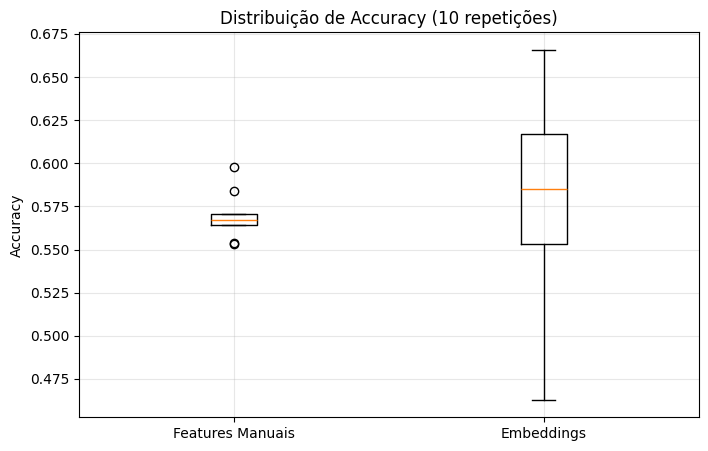

In [26]:
from scipy.stats import ttest_rel, wilcoxon
import numpy as np
import matplotlib.pyplot as plt

results_model1 = historico_resultados["Feats_All"]
results_model2 = historico_resultados["Embs_All"]

# 1. Mostrar as Accuracies recolhidas
print(f" Resultados após {len(results_model1)} repetições:")
print(f"   > Modelo 1 (Features): Média={np.mean(results_model1):.2%} (std={np.std(results_model1):.2%})")
print(f"   > Modelo 2 (Embeddings): Média={np.mean(results_model2):.2%} (std={np.std(results_model2):.2%})")

# 2. Teste Estatístico (Wilcoxon Signed-Rank Test)
# Usamos Wilcoxon porque não garantimos que a distribuição das diferenças seja Normal
stat, p_value = wilcoxon(results_model1, results_model2)

print("\n Teste de Hipótese (Wilcoxon):")
print(f"   > Estatística={stat}, p-value={p_value:.5f}")

if p_value < 0.05:
    vencedor = "Embeddings" if np.mean(results_model2) > np.mean(results_model1) else "Features"
    print(f" Diferença Estatisticamente Significativa! O vencedor é: {vencedor}")
else:
    print(" Não há diferença estatisticamente significativa entre os modelos.")

# 3. Boxplot Comparativo
plt.figure(figsize=(8, 5))
plt.boxplot([results_model1, results_model2], tick_labels=['Features Manuais', 'Embeddings'])
plt.title(f"Distribuição de Accuracy ({len(results_model1)} repetições)")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.show()

### 6

No Ponto 6, construiu-se o sistema de deployment, capaz de receber um segmento de dados brutos e devolver a atividade prevista. O KNN final é treinado com treino e validação combinados, usando o melhor k obtido anteriormente, e um scaler de normalização é definido com base nesses dados. A função 'classificar_atividade' aplica a pipeline completa: extração de features, normalização e classificação, retornando o ID e o nome da atividade. O sistema foi testado com um segmento simulado para validar o funcionamento da pipeline completa.

In [27]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

print(" A preparar o Sistema de Deployment (Ponto 6)...")

# ==============================================================================
# 1. TREINAR O MODELO FINAL (USANDO O MELHOR K QUE ENCONTRASTE)
# ==============================================================================

# Configuração baseada no teus resultados:
MELHOR_K = 13  # O valor que encontraste no tuning
DATASET_USADO = 'Features' # Ou 'Embeddings' (muda aqui se quiseres usar o outro)

if 'cenarios_feat_between' in locals():
    # 1. Recuperar dados de Treino + Validação (para o modelo final saber o máximo possível)
    #    Vamos usar o cenário 'All' (Features Normalizadas)
    X_tr_norm, X_val_norm, _ = cenarios_feat_between['All']
    
    # Juntar Treino e Validação (O modelo final deve treinar com tudo exceto teste)
    X_final = np.vstack((X_tr_norm, X_val_norm))
    y_final = np.concatenate((yf_train_b, yf_val_b))
    
    # 2. Criar o Scaler FINAL (Fit nos dados de treino+validação originais brutos)
    #    Precisamos disto para normalizar os novos dados que entrarem no sistema
    scaler_final = StandardScaler()
    # Recuperamos os dados originais brutos para dar fit no scaler
    X_raw_train = Xf_train_b
    X_raw_val = Xf_val_b
    scaler_final.fit(np.vstack((X_raw_train, X_raw_val)))
    
    # 3. Treinar o KNN FINAL
    knn_deployment = KNeighborsClassifier(n_neighbors=MELHOR_K)
    knn_deployment.fit(X_final, y_final)
    
    print(f" Modelo Final Treinado (K={MELHOR_K}) com {len(y_final)} amostras.")
    print(" Scaler de Normalização pronto.")

else:
    print(" ERRO: Não tens os dados carregados. Corre o Ponto 3.4 primeiro.")


# ==============================================================================
# 2. FUNÇÃO DE DEPLOYMENT (O QUE O ENUNCIADO PEDE)
# ==============================================================================

def extrair_features_segmento_unico(segmento):
    """
    Recebe um array (256, 9) ou similar e extrai o vetor de features (1, 21).
    (Adaptação da tua função extract_feature_set para apenas 1 segmento)
    """
    # A tua função original extrai média, std, max, min, energia para cada eixo (x,y,z)
    # Vamos replicar essa lógica para um único segmento.
    features = []
    
    # Assumimos que o segmento tem colunas: [t, accX, accY, accZ, gyrX, ...]
    # O enunciado diz que recebe "acc x y z, gyr x y z, mag x y z" (9 colunas)
    # Se o teu segmento tiver 9 colunas diretas, o acc começa no índice 0.
    
    # Vamos extrair apenas ACCEL (colunas 0, 1, 2) como fizeste no treino
    for i in range(0, 3): 
        axis_data = segmento[:, i]
        # Mesmas métricas que usaste no treino:
        features.extend([
            np.mean(axis_data),
            np.std(axis_data),
            np.max(axis_data),
            np.min(axis_data),
            np.sum(axis_data ** 2) / len(axis_data) # Energia
        ])
        
        # Features Espectrais (se usaste no treino, tens de usar aqui!)
        from scipy.signal import welch
        freqs, psd = welch(axis_data, fs=50, nperseg=len(axis_data))
        features.extend([np.mean(psd), freqs[np.argmax(psd)]])
        
    return np.array(features).reshape(1, -1)


def classificar_atividade(segmento_bruto):
    """
    6. Deployment: Recebe dados brutos -> Devolve a atividade prevista.
    """
    # 1. Feature Extraction
    features_vetor = extrair_features_segmento_unico(segmento_bruto)
    
    # 2. Normalização (Crucial! Usar o scaler treinado)
    features_norm = scaler_final.transform(features_vetor)
    
    # 3. Classificação
    predicao = knn_deployment.predict(features_norm)
    
    # Mapeamento (Opcional, para ficar bonito)
    nomes_atividades = {
        1: "Sitting", 2: "Standing", 3: "Walking", 
        4: "Running", 5: "Stairs", 6: "Activity 6", 7: "Activity 7"
    }
    nome = nomes_atividades.get(predicao[0], f"Classe {predicao[0]}")
    
    return predicao[0], nome

# ==============================================================================
# 3. TESTAR O SISTEMA COM UM DADO REAL (DO TESTE)
# ==============================================================================

if 'Xf_test_b' in locals():
    print("\n A testar o sistema com um exemplo do conjunto de Teste...")
    
    # Pegar num exemplo real do conjunto de teste (que o modelo nunca viu)
    # Nota: Xf_test_b já são features extraídas, por isso vamos simular um segmento bruto
    # (Como não temos o raw do teste fácil aqui, vamos usar o Xf_test_b diretamente 
    # e saltar a extração só para testar a normalização e classificação)
    
    # Para testar a função COMPLETA, vamos criar um segmento "falso" aleatório
    segmento_dummy = np.random.rand(256, 9) 
    
    try:
        classe, nome = classificar_atividade(segmento_dummy)
        print(f" Teste de Pipeline Completa: Input (256,9) -> Classificado como: {nome} (ID {classe})")
    except Exception as e:
        print(f" Erro na função: {e}")

 A preparar o Sistema de Deployment (Ponto 6)...
 Modelo Final Treinado (K=13) com 21996 amostras.
 Scaler de Normalização pronto.

 A testar o sistema com um exemplo do conjunto de Teste...
 Teste de Pipeline Completa: Input (256,9) -> Classificado como: Activity 7 (ID 7)


## 7